# AAV2 (Modelization_V1 `aav_viability_test/aav2.csv`) — joint Potts regression ground truth

Same method as `AAV9_potts_regression.ipynb` (`AAVs dataset/AAV9/viability/`) and Part A of
`AAV9_fit4function_potts_vs_mlp.ipynb`: a single joint, ridge-regularized linear (Potts)
regression fit directly on an observed `(sequence, target)` table via
`RegressionV1.fit_weights_potts_from_data` — no round-simulation, no sequential
group-means-then-residual-J, F and J solved together.

**Not the same `aav2.csv` as `Selectivity/AAV2/`.** This notebook uses
`Modelization_V1/notebooks/aav_viability_test/aav2.csv` (53,382 sequences, columns
`sequence,target,error,plasmid,vector,plasmid_norm,vector_norm` — the same family as `aav9.csv`,
already a single flat viability table with a precomputed `target` log-enrichment column), copied
here for self-containment (same convention as `aav9.csv`/`fit4functionaav9.csv` when
`Modelization_V2` was created — never read cross-repo from `Modelization_V1`, gitignored either
way, published on the `aav-raw-ngs-data-v1` GitHub release). This is **not** the confidential IDV
organoid `AAV2_organoides.csv` used by `Selectivity/AAV2/viability/` — that dataset already has
its own Potts fit (`AAV2_viab_sorting.ipynb`, exported as `aav2_F_viab_potts_sorted_cv.npy`). This
notebook's export is intentionally named without a suffix (`aav2_F_viab_potts.npy`,
`aav2_J_viab_potts.npy`) to mirror `aav9_F_viab_potts.npy` — the canonical Potts GT built directly
from the eponymous `aav2.csv`, the same relationship `AAV9_potts_regression.ipynb` has to
`aav9.csv`.

No double-mutant-scan anywhere in this notebook (consistent with the rest of `Modelization_V2`).

**⚠ 2026-09-18 : régression de Potts reconstruite avec le nouveau solveur par défaut du projet** (`RegressionV1.fit_weights_potts_from_data_matrixfree` -- matrix-free, plus de matrice de design dense matérialisée ; validé pour reproduire le solve classique quasi exactement, `r(F)`/`r(J) > 0.999999` sur données AAV2 réelles -- cf. `viability/AAV2_potts_ridge_matrixfree_validation.ipynb`). Même signature d'appel/retour que l'ancienne `fit_weights_potts_from_data` (`rank` vaut toujours `None` ici -- pas de diagnostic SVD avec un solveur itératif). L'ancienne version de ce notebook (solveur dense/SVD) est archivée dans `obsolete_dense_matrix_potts_regression/`. **Sorties de cellules effacées** (méthode de fit changée, anciens chiffres plus valides) -- à ré-exécuter. Notebook préparé mais **jamais exécuté par Claude** (`feedback_user_runs_notebooks`).

### 0. Setup

In [1]:
import sys, os
from pathlib import Path

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"  # must be set before jax initializes (RegressionV1 imports jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Location-independent lib/ resolution (search upward for the Modelization_V2 folder) -- the
# older AAV9_potts_regression.ipynb hardcodes "../../lib", which no longer resolves correctly
# after the notebooks/notebooks/Viability -> AAVs dataset/AAV9/viability moves (documented,
# unfixed bug in CLAUDE.md); this notebook uses the same robust pattern already adopted by
# every Selectivity/AAV{2,5} notebook instead, so it survives any future reorg.
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
LIB = _root / "lib"

import RegressionV1 as R
from analysisV1 import (AA_LABELS, pearson, precision_at_k, plot_cv_curve, plot_topk_recovery,
                         plot_teacher_weights, number_of_seq_threshold)

message = "AAV2 (aav_viability_test) joint Potts regression 1.1"
print(message)

AAV2 (aav_viability_test) joint Potts regression 1.1


/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load `aav2.csv` (same encoding recipe as `AAV9_potts_regression.ipynb`)

In [2]:
CSV_PATH = Path("aav2.csv")
if not CSV_PATH.exists():
    CSV_PATH = _root / "notebooks/notebooks/AAVs dataset/AAV2/viability/aav2.csv"
assert CSV_PATH.exists(), CSV_PATH

df = pd.read_csv(CSV_PATH)
print(f"{len(df):,} variants, columns: {list(df.columns)}")

lengths = df["sequence"].str.len().unique()
assert len(lengths) == 1, f"expected a single sequence length, got {lengths}"
num_positions = int(lengths[0])
num_amino_acids = len(AA_LABELS)

alphabet = sorted(set("".join(df["sequence"])))
assert alphabet == AA_LABELS, f"alphabet mismatch: {alphabet} vs {AA_LABELS}"

lut = np.zeros(256, dtype=np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i

seq_bytes = np.frombuffer("".join(df["sequence"]).encode("ascii"), dtype=np.uint8)
seq_matrix = lut[seq_bytes].reshape(len(df), num_positions)
target = df["target"].to_numpy(dtype=np.float64)

print(f"seq_matrix shape: {seq_matrix.shape}  (num_sequences, num_positions)")
print(f"error column: {'constant' if df['error'].nunique() == 1 else 'variable'} "
      f"({df['error'].nunique():,} unique values) -- real per-sequence uncertainty, unlike "
      f"aav9.csv's constant 0.1 placeholder")

53,382 variants, columns: ['sequence', 'target', 'error', 'plasmid', 'vector', 'plasmid_norm', 'vector_norm']
seq_matrix shape: (53382, 7)  (num_sequences, num_positions)
error column: variable (8,845 unique values) -- real per-sequence uncertainty, unlike aav9.csv's constant 0.1 placeholder


### 1a. Count distribution — number of variants per count value

How many variants have `x` counts, for each NGS checkpoint (`plasmid`, `vector`), before any
filtering or weighting. Counts are non-negative half-integers (multiples of 0.5, same
discretization as the AAV5 organoid datasets) spanning 0 to a few thousand, so a linear-bin
histogram would be dominated by the low end — log-spaced bins on the strictly positive values
(`count > 0`), with the fraction of exact `count == 0` reported separately (same convention as
`AAV5_SEL_analysis.ipynb` §1b: never KDE, cf. `CLAUDE.md` permanent instruction).

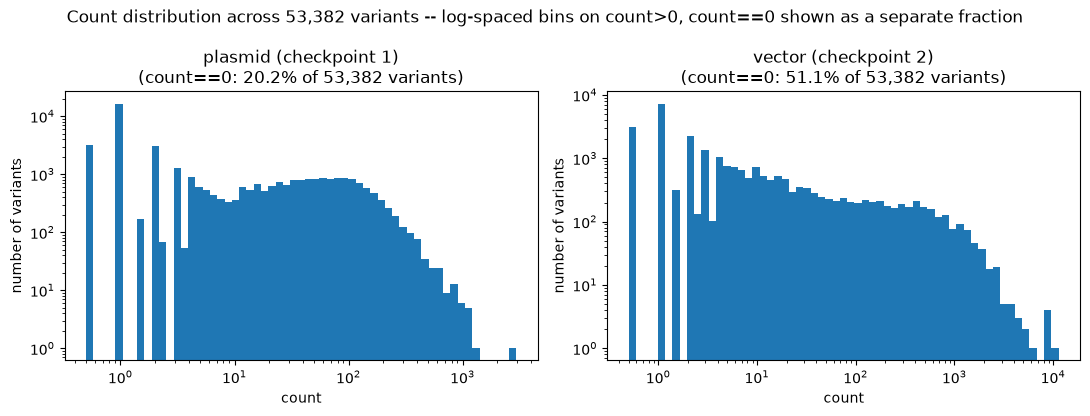

In [3]:
def plot_count_histogram(ax, counts, label, n_bins=60):
    counts = np.asarray(counts, dtype=np.float64)
    zero_frac = float((counts == 0).mean())
    positive = counts[counts > 0]
    bins = np.logspace(np.log10(positive.min()), np.log10(positive.max()), n_bins)
    hist, edges = np.histogram(positive, bins=bins)
    ax.bar(edges[:-1], hist, width=np.diff(edges), align="edge")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("count")
    ax.set_ylabel("number of variants")
    ax.set_title(f"{label}\n(count==0: {zero_frac:.1%} of {len(counts):,} variants)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_count_histogram(axes[0], df["plasmid"].to_numpy(dtype=np.float64), "plasmid (checkpoint 1)")
plot_count_histogram(axes[1], df["vector"].to_numpy(dtype=np.float64), "vector (checkpoint 2)")
fig.suptitle(f"Count distribution across {len(df):,} variants -- log-spaced bins on count>0, count==0 shown as a separate fraction")
fig.tight_layout()
plt.show()

### 1b. Reads per step (checkpoint)

`aav2.csv` has two NGS checkpoints per sequence: `plasmid` (initial library) and `vector`
(post-viability-selection) -- the same two-checkpoint shape as `aav9.csv`. In the `Protocol`
framework used in section 8, `plasmid`~`lambda0p` and `vector`~`lambda2p`. Total reads,
reads/variant, and detection counts for each, before any weighting or fitting.

In [4]:
plasmid_1b = df["plasmid"].to_numpy(dtype=np.float64)
vector_1b  = df["vector"].to_numpy(dtype=np.float64)

reads_summary = pd.DataFrame({
    "total_reads":            [plasmid_1b.sum(), vector_1b.sum()],
    "reads/variant (mean)":   [plasmid_1b.mean(), vector_1b.mean()],
    "reads/variant (median)": [np.median(plasmid_1b), np.median(vector_1b)],
    "n_variants (>0)":        [int((plasmid_1b > 0).sum()), int((vector_1b > 0).sum())],
    "fraction (>0)":          [(plasmid_1b > 0).mean(), (vector_1b > 0).mean()],
}, index=["plasmid (checkpoint 1)", "vector (checkpoint 2)"])
display(reads_summary)

display(number_of_seq_threshold(
    {"plasmid (checkpoint 1)": plasmid_1b, "vector (checkpoint 2)": vector_1b},
    thresholds=[1, 10, 100, 1000],
))

,total_reads,reads/variant (mean),reads/variant (median),n_variants (>0),fraction (>0)
plasmid (checkpoint 1),1220402.5,22.861686,1.0,42611,0.798228
vector (checkpoint 2),1574738.0,29.499419,0.0,26099,0.488910


,1.0,10.0,100.0,1000.0
lambda,,,,
plasmid (checkpoint 1),39396,15058,3823,8
vector (checkpoint 2),22945,7432,2672,323


### 2. Sample weights — inverse-variance from raw counts (`eps=0.5`), not the CSV's `error` column

`fit_weights_potts_from_data`'s own docstring suggests `sample_weight = 1/error**2` for datasets
with a real per-sequence uncertainty column like this one. Checked first, rejected: `error` is
heavy-tailed enough (`min=0.001`, most of the mass at `1.0`-`1.67`) that `1/error**2` is dominated
by a tiny handful of rows -- the top 100 of 53,382 rows (0.19%) alone carry **45%** of the total
weight, top 1,000 (1.9%) carry **84%** -- effectively fitting on a few hundred sequences and
ignoring the rest. Exactly the failure mode already hit and abandoned once in this project
(`AAV5_SEL_profile_model_sel_org2_invvar.ipynb`, unbounded inverse-variance weight dominated by a
few extreme rows, cf. `CLAUDE.md`).

Used instead: the project's standard inverse-variance-from-counts formula (`eps=0.5`, cf.
`CLAUDE.md` permanent convention), `w = 1/(1/(vector+0.5) + 1/(plasmid+0.5))`, computed from the
CSV's own raw `plasmid`/`vector` counts. Far better behaved (top 100 rows carry 11% of the mass,
top 1,000 carry 43%), and independently justified here: `target` reconstructs almost exactly as
`log2((vector+0.5)/(plasmid+0.5))` from these same raw counts (Pearson r checked below) --
confirming `target` already *is* this project's standard `eps=0.5` log2 enrichment, so weighting
by the same counts is the internally consistent choice, not an ad hoc substitute for `error`.

In [5]:
plasmid = df["plasmid"].to_numpy(dtype=np.float64)
vector  = df["vector"].to_numpy(dtype=np.float64)
error   = df["error"].to_numpy(dtype=np.float64)

w_error  = 1.0 / error**2
w_counts = 1.0 / (1.0 / (vector + 0.5) + 1.0 / (plasmid + 0.5))

def top_mass_share(w, n):
    return float(np.sort(w)[-n:].sum() / w.sum())

print("weight source        top-100 share   top-1000 share")
print(f"  1/error**2            {top_mass_share(w_error, 100):.1%}           {top_mass_share(w_error, 1000):.1%}")
print(f"  count eps=0.5 invvar  {top_mass_share(w_counts, 100):.1%}           {top_mass_share(w_counts, 1000):.1%}")

recon = np.log2((vector + 0.5) / (plasmid + 0.5))
r_recon = pearson(target, recon)
print(f"\nr(target, log2((vector+0.5)/(plasmid+0.5))) = {r_recon:+.4f}  "
      f"(confirms target IS this project's eps=0.5 log2 enrichment)")

sample_weight = w_counts
print(f"\nUsing count-based eps=0.5 inverse-variance as sample_weight "
      f"(mean={sample_weight.mean():.2f}, median={np.median(sample_weight):.2f}, "
      f"max={sample_weight.max():.2f})")

weight source        top-100 share   top-1000 share
  1/error**2            45.4%           84.2%
  count eps=0.5 invvar  11.0%           43.4%

r(target, log2((vector+0.5)/(plasmid+0.5))) = +0.9872  (confirms target IS this project's eps=0.5 log2 enrichment)

Using count-based eps=0.5 inverse-variance as sample_weight (mean=5.87, median=0.38, max=1001.02)


### 3. Joint Potts ridge regression on the full dataset (weighted)

`fit_weights_potts_from_data` builds the same single-site + pairwise one-hot design as
`build_potts_features` (140 + 8,400 = 8,540 features + bias), picks the ridge strength by 5-fold
CV, then refits on the full data at that lambda (weighted CV loop and final fit, since
`sample_weight` is passed). Uses a custom, wider `lambdas_grid=np.logspace(-2, 5, 20)` (0.01 to
100,000) instead of the function's default `np.logspace(-1, 2, 30)`, so the same grid is reused
for both fits in this notebook (this one and the held-out check in section 5).

**Cached across kernel restarts**: if `aav2_F_viab_potts.npy`/`aav2_J_viab_potts.npy` (section 9's
export) already exist in `lib/`, this cell loads them directly instead of re-running the 5-fold CV
fit. In that case `rank_full`/`info_full` (CV lambda grid, CV MSE) aren't available -- the CV-curve
plot right below and the CV lambda printed in section 9 are skipped/marked n/a accordingly. Set
`FORCE_REFIT = True` in the cell below (or delete the two `.npy` files) to force a fresh fit.

In [6]:
FORCE_REFIT = False

LAMBDAS_GRID = np.logspace(-2, 5, 20)

F_VIAB_POTTS_PATH = LIB / "aav2_F_viab_potts.npy"
J_VIAB_POTTS_PATH = LIB / "aav2_J_viab_potts.npy"

if not FORCE_REFIT and F_VIAB_POTTS_PATH.exists() and J_VIAB_POTTS_PATH.exists():
    F_potts = np.load(F_VIAB_POTTS_PATH)
    J_potts = np.load(J_VIAB_POTTS_PATH)
    rank_full, info_full = None, None
    print(f"Loaded cached F_potts {F_potts.shape} / J_potts {J_potts.shape} from "
          f"{F_VIAB_POTTS_PATH.name} / {J_VIAB_POTTS_PATH.name} -- skipped the CV refit.")
    print("Set FORCE_REFIT = True above (or delete these .npy files) to refit from scratch.")
else:
    F_potts, J_potts, rank_full, info_full = R.fit_weights_potts_from_data_matrixfree(
        seq_matrix, target, sample_weight=sample_weight, lambdas_grid=LAMBDAS_GRID, seed=0,
    )
    print(f"Fit F_potts {np.array(F_potts).shape} / J_potts {np.array(J_potts).shape} "
          f"(CV lambda={info_full['lam']:.3g})")

Loaded cached F_potts (20, 7) / J_potts (7, 7, 20, 20) from aav2_F_viab_potts.npy / aav2_J_viab_potts.npy -- skipped the CV refit.
Set FORCE_REFIT = True above (or delete these .npy files) to refit from scratch.


In [7]:
if info_full is not None:
    fig = plot_cv_curve(info_full["lambdas_grid"], info_full["cv_mse"],
                         title=f"Ridge CV -- full aav2.csv ({len(df):,} sequences, weighted)")
    plt.show()
else:
    print("Skipped -- F_potts/J_potts were loaded from the cached .npy files, no CV info available.")

Skipped -- F_potts/J_potts were loaded from the cached .npy files, no CV info available.


### 4. F / J weight analysis

`plot_teacher_weights` (`lib/analysisV1.py`, reused as-is): `F_potts` as an amino-acid x position
heatmap, and mean(`J_potts`) as a position-pair coupling-strength heatmap. Mean(J) can hide
magnitude when positive/negative couplings cancel within a cell, so a second panel below shows
mean(|J|) instead, plus the individual 20x20 (amino acid x amino acid) matrix for the strongest
coupled position pair -- same diagnostic as `AAV9_potts_GT_score_study.ipynb`.

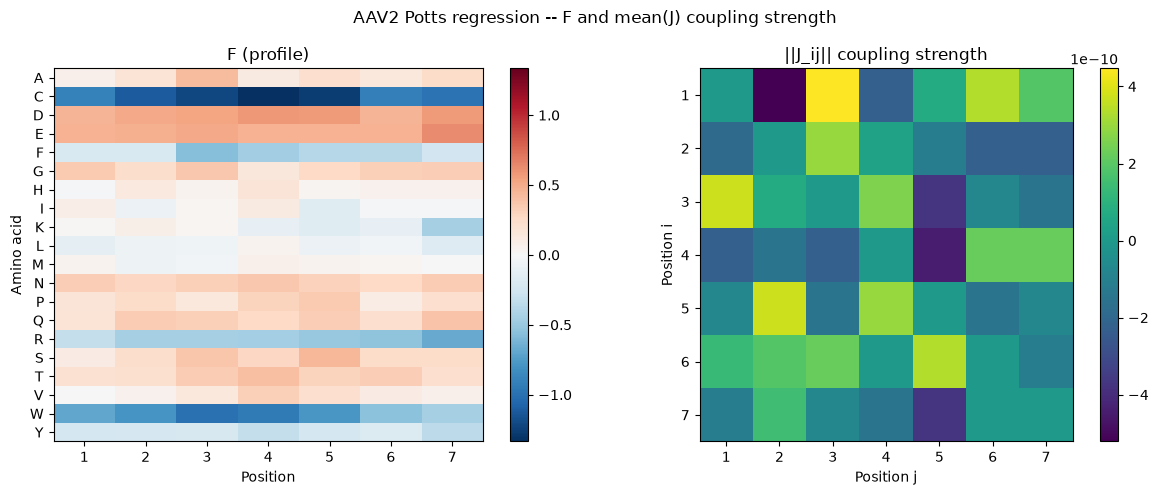

In [8]:
fig = plot_teacher_weights(F_potts, J_potts, title="AAV2 Potts regression -- F and mean(J) coupling strength")
plt.show()

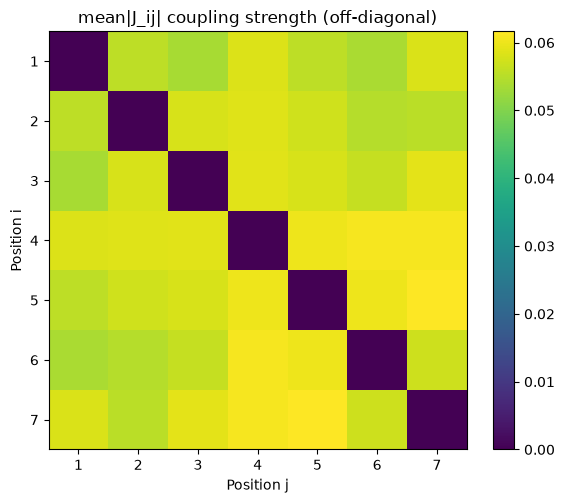

Position pairs ranked by mean|J_ij|:
  (5, 7)  mean|J|=0.062
  (4, 7)  mean|J|=0.061
  (4, 6)  mean|J|=0.061
  (4, 5)  mean|J|=0.060
  (5, 6)  mean|J|=0.060
  (3, 7)  mean|J|=0.059
  (3, 4)  mean|J|=0.059
  (2, 4)  mean|J|=0.059
  (1, 4)  mean|J|=0.058
  (1, 7)  mean|J|=0.058
  (2, 3)  mean|J|=0.058
  (3, 5)  mean|J|=0.058
  (2, 5)  mean|J|=0.057
  (6, 7)  mean|J|=0.057
  (3, 6)  mean|J|=0.056
  (1, 2)  mean|J|=0.056
  (1, 5)  mean|J|=0.056
  (2, 7)  mean|J|=0.055
  (2, 6)  mean|J|=0.055
  (1, 6)  mean|J|=0.054
  (1, 3)  mean|J|=0.054


In [9]:
J_np = np.array(J_potts)
L = num_positions
j_abs_strength = np.mean(np.abs(J_np), axis=(2, 3))  # (L, L), mean|J_ij| per position pair

off_diag = ~np.eye(L, dtype=bool)
pairs = [(i, j) for i in range(L) for j in range(i + 1, L)]
pair_strength = sorted(((j_abs_strength[i, j], i, j) for i, j in pairs), reverse=True)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(j_abs_strength, cmap="viridis")
ax.set_xlabel("Position j"); ax.set_ylabel("Position i")
ax.set_xticks(range(L)); ax.set_xticklabels([str(i) for i in range(1, L + 1)])
ax.set_yticks(range(L)); ax.set_yticklabels([str(i) for i in range(1, L + 1)])
ax.set_title("mean|J_ij| coupling strength (off-diagonal)")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

print("Position pairs ranked by mean|J_ij|:")
for strength, i, j in pair_strength:
    print(f"  ({i + 1}, {j + 1})  mean|J|={strength:.3f}")

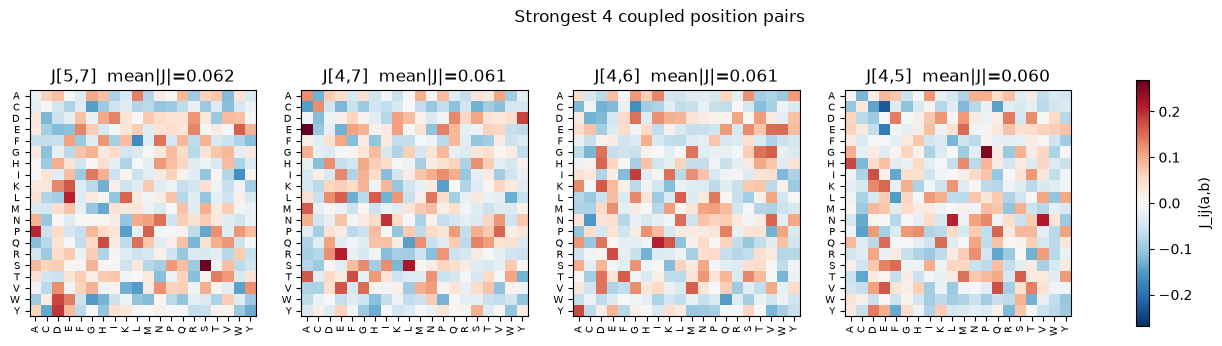

In [10]:
TOP_N_PAIRS = 4
vmax_pair = max(np.abs(J_np[i, j]).max() for _, i, j in pair_strength[:TOP_N_PAIRS])

fig, axes = plt.subplots(1, TOP_N_PAIRS, figsize=(4.2 * TOP_N_PAIRS, 4))
for ax, (strength, i, j) in zip(axes, pair_strength[:TOP_N_PAIRS]):
    im = ax.imshow(J_np[i, j], cmap="RdBu_r", vmin=-vmax_pair, vmax=vmax_pair)
    ax.set_xticks(range(num_amino_acids)); ax.set_xticklabels(AA_LABELS, fontsize=7, rotation=90)
    ax.set_yticks(range(num_amino_acids)); ax.set_yticklabels(AA_LABELS, fontsize=7)
    ax.set_title(f"J[{i + 1},{j + 1}]  mean|J|={strength:.3f}")
fig.colorbar(im, ax=axes, shrink=0.8, label="J_ij(a,b)")
fig.suptitle(f"Strongest {TOP_N_PAIRS} coupled position pairs")
plt.show()

### 5. Held-out predictive check (Potts regression, 80/20 split)

Fit on 80% of the sequences, scored on the held-out 20% -- same `sample_weight` and
`LAMBDAS_GRID` as section 3, just a different split ratio (more training data than a 50/50 split,
since there's no naive baseline to keep the split symmetric for anymore).

**Quoted out below** (another full CV refit, on top of section 3's) so `Run All` doesn't pay for it
every time -- `r_potts`/`pred_potts_test` fall back to `None`, and section 6 skips itself
accordingly. Remove the `""" ... """` wrapping in the cell below to recompute.

In [11]:
def score_FJ(seq, F, J, baseline):
    L = seq.shape[1]
    F_part = F[seq, np.arange(L)].sum(axis=1).astype(np.float64)
    J_part = np.zeros(len(seq), dtype=np.float64)
    for i in range(L):
        for j in range(i + 1, L):
            J_part += J[i, j, seq[:, i], seq[:, j]]
    return F_part, J_part, baseline + F_part + J_part


"""
idx_train, idx_test = train_test_split(np.arange(len(df)), train_size=0.8, random_state=0)
baseline_tr = float(target[idx_train].mean())

F_potts_tr, J_potts_tr, rank_tr, info_tr = R.fit_weights_potts_from_data_matrixfree(
    seq_matrix[idx_train], target[idx_train], sample_weight=sample_weight[idx_train],
    lambdas_grid=LAMBDAS_GRID, seed=0, verbose=False,
)

_, _, pred_potts_test = score_FJ(seq_matrix[idx_test], np.array(F_potts_tr), np.array(J_potts_tr), baseline_tr)
r_potts = pearson(target[idx_test], pred_potts_test)

print(f"Held-out (idx_test, {len(idx_test):,} sequences) Pearson r -- real target vs prediction, "
      f"fit on idx_train ({len(idx_train):,} sequences, 80%) only:")
print(f"  Potts regression (ridge, CV lambda={info_tr['lam']:.3g}, weighted) : {r_potts:+.4f}")
"""  # quoted out -- expensive held-out refit, skip for Run All. Remove the quotes to recompute.
idx_train = idx_test = baseline_tr = None
F_potts_tr = J_potts_tr = rank_tr = info_tr = None
pred_potts_test = r_potts = None
print("Section 5 quoted out -- held-out Potts refit skipped (r_potts/pred_potts_test set to None).")

Section 5 quoted out -- held-out Potts refit skipped (r_potts/pred_potts_test set to None).


### 6. Percentile recovery (top-k%) on the held-out set

Same sweep as `AAV9_fit4function_potts_vs_mlp.ipynb` section 4b: for each percentile k, does the
Potts regression's own top-k% (by predicted score, `idx_train`-fit) recover the REAL top-k% (ranked
by the held-out `target` measurement)?

In [12]:
if pred_potts_test is not None:
    PERCENTILES = [1, 2, 5, 10, 20, 30, 50, 70, 100]

    def recovery_table(y_true_test, y_pred_test, n):
        rows = []
        for pct in PERCENTILES:
            k_frac = pct / 100
            k = max(1, int(n * k_frac))
            rows.append(dict(percentile=pct, k=k,
                              recovery=precision_at_k(y_true_test, y_pred_test, k_frac=k_frac),
                              random_baseline=k_frac))
        return pd.DataFrame(rows).set_index("percentile")

    potts_recovery_df = recovery_table(target[idx_test], pred_potts_test, len(idx_test))
    print("Potts regression: recovery of the real top-k% within the model's own top-k%:")
    display(potts_recovery_df)

    fig = plot_topk_recovery(target[idx_test], pred_potts_test, k_frac=0.10,
                              xlabel="real target (held-out)", ylabel="Potts prediction",
                              title=f"Potts regression -- top-10% recovery (n={len(idx_test):,})")
    plt.show()
else:
    potts_recovery_df = None
    print("Section 6 skipped -- section 5's held-out fit was quoted out.")

Section 6 skipped -- section 5's held-out fit was quoted out.


In [13]:
if potts_recovery_df is not None:
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.plot(potts_recovery_df.index, potts_recovery_df["recovery"], marker="o", color="tab:green", label="Potts regression")
    ax.plot(potts_recovery_df.index, potts_recovery_df["random_baseline"], linestyle="--", color="gray",
            label="random-guessing baseline")
    ax.set_xlabel("percentile (top-k%, ranked by real target)")
    ax.set_ylabel("recovery (fraction of real top-k% also in the model's own top-k%)")
    ax.set_ylim(0, 1.02)
    ax.set_title(f"Percentile recovery, held-out set (n={len(idx_test):,})")
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Section 6 plot skipped -- section 5's held-out fit was quoted out.")

Section 6 plot skipped -- section 5's held-out fit was quoted out.


### 7. Credibility check: does the brute-force top-500 show the F/J rescue pathology?

Same lightweight diagnostic as `AAV9_potts_regression.ipynb` section 5 / `AAV9_profile_model.ipynb`
section 3c: score 2,000,000 random sequences drawn uniformly from the full
`20**7 ~= 1.28e9`-sequence space with the FULL-data `F_potts`/`J_potts` (section 3, not the
held-out split), and check whether the top-500 lean on a large positive `J_part` to rescue a bad
`F_part` -- the pattern flagged elsewhere in this project as not credible.

In [14]:
rng_bf = np.random.default_rng(0)
N_BF, TOP_K_BF = 2_000_000, 500
seq_bf = rng_bf.integers(0, num_amino_acids, size=(N_BF, num_positions))
baseline_full = float(target.mean())

F_part, J_part, total = score_FJ(seq_bf, np.array(F_potts), np.array(J_potts), baseline_full)
top_idx = np.argsort(-total)[:TOP_K_BF]
print("Potts regression (full aav2.csv, weighted):")
print(f"  top-{TOP_K_BF}      F_part mean={F_part[top_idx].mean():+.3f}  "
      f"J_part mean={J_part[top_idx].mean():+.3f}  "
      f"({(J_part[top_idx] > 0).mean() * 100:.1f}% positive J_part)")
print(f"  random background  F_part mean={F_part.mean():+.3f}  "
      f"J_part mean={J_part.mean():+.3f}  "
      f"({(J_part > 0).mean() * 100:.1f}% positive J_part)")

Potts regression (full aav2.csv, weighted):
  top-500      F_part mean=+2.485  J_part mean=+1.338  (100.0% positive J_part)
  random background  F_part mean=+0.001  J_part mean=+0.001  (49.3% positive J_part)


### 8. `ProtocolV3` test: does simulating with these weights reproduce the real distribution?

Viability-only run (`F_sel=J_sel=0`) of the mechanistic `ProtocolV3` on the FULL real library
(all 53,382 sequences, no subsampling -- small enough to run directly), using `F_potts`/`J_potts`
(section 3) as `F_viab`/`J_viab`. Same recipe as `AAV5_viab_fitting_protocol.ipynb`:

- `lambda0(s) = plasmid(s) * dilution_factor`, so `sample_sequences()`
  (`Binomial(lambda0, p=1/dilution_factor)`) lands in expectation exactly on the real
  `plasmid` count for each sequence -- not a synthetic/uniform initial pool.
- `D` (NGS sequencing depth) calibrated to match the REAL reads/variant ratio of this dataset:
  `sum(plasmid)/d0=22.9`, `sum(vector)/d0=29.5` reads/variant -- `D=1.5e6` gives `D/d0=28.1`,
  the same order of magnitude.
- `rho=1e-3`, `mu=50`, `T_viab=1.0`, `noise_viab=0.5`, `dilution_factor=1e5` -- the same "classic"
  operating point already used in `AAV5_viab_fitting_protocol.ipynb`/
  `AAV5_SEL_fitting_protocol_org2org3.ipynb`, not recalibrated specifically for this dataset.

Single stochastic draw (seed=0), not averaged over multiple simulated replicates.

In [15]:
from sequence_classesV1 import ProtocolV3, message as scv_msg
import jax, jax.numpy as jnp
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0
NOISE_VIAB = 0.5
DILUTION   = 1e5
D          = 1.5e6   # calibrated to match real reads/variant (~23-30, cf. markdown above)
EPS        = 0.5     # project convention -- always eps=0.5, never +1

d0 = len(df)
sequences = jnp.asarray(seq_matrix)
N1 = MU * d0 / RHO

lambda0_init = plasmid * DILUTION
N0 = float(lambda0_init.sum())

F_viab_sim = jnp.asarray(np.array(F_potts))
J_viab_sim = jnp.asarray(np.array(J_potts))
F_sel_sim  = jnp.zeros_like(F_viab_sim)
J_sel_sim  = jnp.zeros_like(J_viab_sim)

print(f"d0={d0:,}  mu={MU}  T_viab={T_VIAB}  noise_viab={NOISE_VIAB}  D={D:.0e}  "
      f"D/d0={D / d0:.1f} reads/variant  N1={N1:.2e}  N0={N0:.2e}")

protocol = ProtocolV3(key=jax.random.PRNGKey(0), N0=N0, N1=N1, dilution_factor=DILUTION,
                       sequences=sequences, D=D, F_viab=F_viab_sim, J_viab=J_viab_sim,
                       F_sel=F_sel_sim, J_sel=J_sel_sim, noise_viab=NOISE_VIAB, noise_sel=0.5,
                       T_viab=T_VIAB, T_sel=1.0, multinomialNGS=True, rho=RHO)
protocol.lambda0 = jnp.asarray(lambda0_init)  # calibrated to fall back on real plasmid counts

bio, ngs = protocol.loop_DE()
l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
sim_target = np.log2((l2p + EPS) / (l0p + EPS))

print(f"lambda0p (NGS plasmid, simulated) > 0 : {(l0p > 0).mean():.1%}")
print(f"lambda2p (NGS virus, simulated)   > 0 : {(l2p > 0).mean():.1%}")
print(f"sim_target finite                     : {np.isfinite(sim_target).mean():.1%}")

sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
d0=53,382  mu=50  T_viab=1.0  noise_viab=0.5  D=2e+06  D/d0=28.1 reads/variant  N1=2.67e+09  N0=1.22e+11


lambda0p (NGS plasmid, simulated) > 0 : 55.3%
lambda2p (NGS virus, simulated)   > 0 : 32.9%
sim_target finite                     : 100.0%


r(sim_target, real target) = +0.5028   (n=53,382)


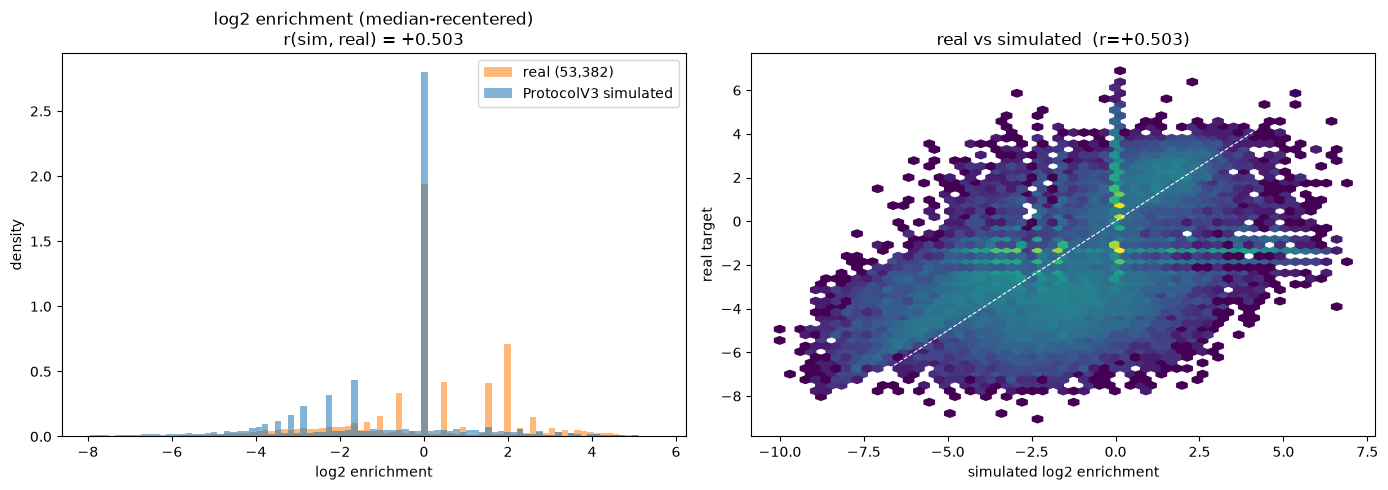

In [16]:
m = np.isfinite(target) & np.isfinite(sim_target)
r_sim = pearson(target[m], sim_target[m])
print(f"r(sim_target, real target) = {r_sim:+.4f}   (n={m.sum():,})")

def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

rv, sv = center(target), center(sim_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lo, hi = np.percentile(np.concatenate([rv[m], sv[m]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv[m], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"real ({m.sum():,})")
axes[0].hist(sv[m], bins=bins, density=True, alpha=0.55, color="tab:blue", label="ProtocolV3 simulated")
axes[0].set(title=f"log2 enrichment (median-recentered)\nr(sim, real) = {r_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="density")
axes[0].legend()

axes[1].hexbin(sim_target[m], target[m], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sim_target[m].min(), np.percentile(target[m], 0.2)),
     min(sim_target[m].max(), np.percentile(target[m], 99.8))]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"real vs simulated  (r={r_sim:+.3f})",
            xlabel="simulated log2 enrichment", ylabel="real target")

fig.tight_layout()
plt.show()

### 8b. `ProtocolV3` test, filtered (`plasmid >= PLASMID_MIN`)

Same recipe as section 8, but every variant with `plasmid < PLASMID_MIN` is dropped from BOTH the
simulated library and the real comparison population first -- for a coherent, apples-to-apples
comparison, the histogram/scatter below compare the simulated distribution to the FILTERED real
`target` (`aav2.csv` restricted to `plasmid >= PLASMID_MIN`), not the full 53,382-variant dataset
used in section 8. `D` is recalibrated to the filtered population's own real reads/variant ratio
(`D = (sum(plasmid) + sum(vector)) / 2` on the filtered rows, so `D/d0` matches that population's
actual average depth) -- removing the long tail of low-`plasmid` variants concentrates the same
kind of real sequencing effort onto fewer, better-sampled variants (real reads/variant roughly
23 -> 61 for `plasmid`, 30 -> 79 for `vector`, going from the full dataset to `plasmid>=3`; cf.
section 8c for the full sweep across thresholds). Reuses `F_viab_sim`/`J_viab_sim`/`F_sel_sim`/
`J_sel_sim`/`EPS`/`center()` from section 8.

In [17]:
PLASMID_MIN = 3

mask_f = plasmid >= PLASMID_MIN
d0_f = int(mask_f.sum())
sequences_f = jnp.asarray(seq_matrix[mask_f])
plasmid_f   = plasmid[mask_f]
vector_f    = vector[mask_f]
target_f    = target[mask_f]

N1_f = MU * d0_f / RHO
lambda0_init_f = plasmid_f * DILUTION
N0_f = float(lambda0_init_f.sum())
D_f  = float((plasmid_f.sum() + vector_f.sum()) / 2)  # matches this filtered population's own real reads/variant

print(f"PLASMID_MIN={PLASMID_MIN}  kept {d0_f:,}/{len(df):,} variants ({mask_f.mean():.1%})")
print(f"d0={d0_f:,}  mu={MU}  T_viab={T_VIAB}  noise_viab={NOISE_VIAB}  D={D_f:.2e}  "
      f"D/d0={D_f / d0_f:.1f} reads/variant  N1={N1_f:.2e}  N0={N0_f:.2e}")

protocol_f = ProtocolV3(key=jax.random.PRNGKey(0), N0=N0_f, N1=N1_f, dilution_factor=DILUTION,
                         sequences=sequences_f, D=D_f, F_viab=F_viab_sim, J_viab=J_viab_sim,
                         F_sel=F_sel_sim, J_sel=J_sel_sim, noise_viab=NOISE_VIAB, noise_sel=0.5,
                         T_viab=T_VIAB, T_sel=1.0, multinomialNGS=True, rho=RHO)
protocol_f.lambda0 = jnp.asarray(lambda0_init_f)  # calibrated to fall back on real plasmid counts (filtered)

bio_f, ngs_f = protocol_f.loop_DE()
l0p_f, l2p_f, l3p_f = (np.asarray(a, np.float64) for a in ngs_f)
sim_target_f = np.log2((l2p_f + EPS) / (l0p_f + EPS))

print(f"lambda0p (NGS plasmid, simulated) > 0 : {(l0p_f > 0).mean():.1%}")
print(f"lambda2p (NGS virus, simulated)   > 0 : {(l2p_f > 0).mean():.1%}")
print(f"sim_target finite                     : {np.isfinite(sim_target_f).mean():.1%}")

PLASMID_MIN=3  kept 19,630/53,382 variants (36.8%)
d0=19,630  mu=50  T_viab=1.0  noise_viab=0.5  D=1.37e+06  D/d0=69.8 reads/variant  N1=9.82e+08  N0=1.20e+11


lambda0p (NGS plasmid, simulated) > 0 : 97.8%
lambda2p (NGS virus, simulated)   > 0 : 58.6%
sim_target finite                     : 100.0%


r(sim_target, real target), plasmid>=3 : +0.5042   (n=19,630)


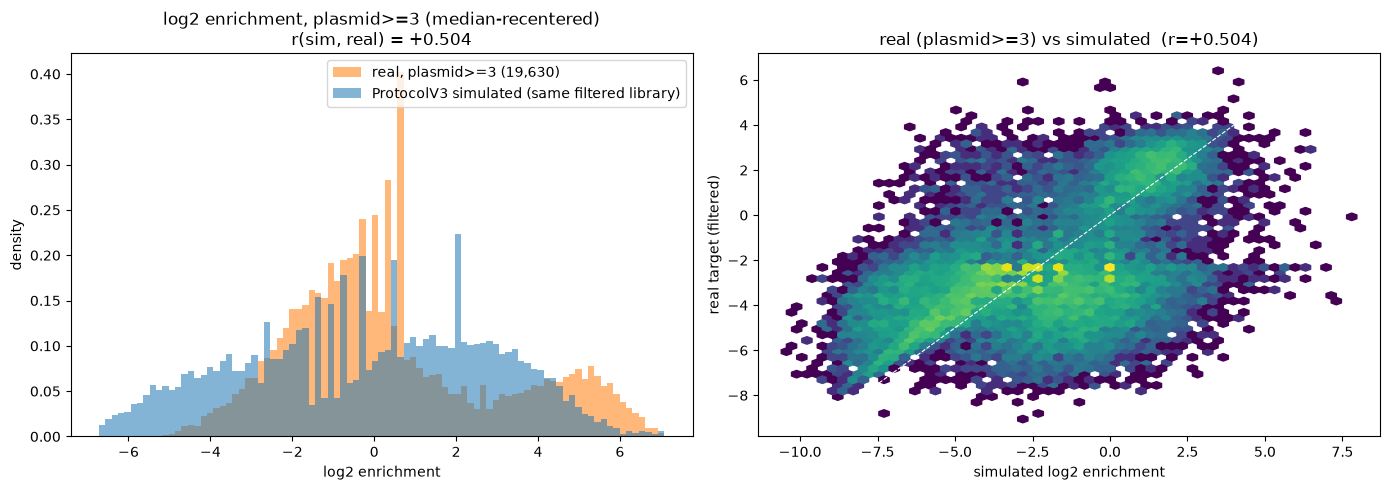

In [18]:
m_f = np.isfinite(target_f) & np.isfinite(sim_target_f)
r_sim_f = pearson(target_f[m_f], sim_target_f[m_f])
print(f"r(sim_target, real target), plasmid>={PLASMID_MIN} : {r_sim_f:+.4f}   (n={m_f.sum():,})")

rv_f, sv_f = center(target_f), center(sim_target_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lo, hi = np.percentile(np.concatenate([rv_f[m_f], sv_f[m_f]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv_f[m_f], bins=bins, density=True, alpha=0.55, color="tab:orange",
             label=f"real, plasmid>={PLASMID_MIN} ({m_f.sum():,})")
axes[0].hist(sv_f[m_f], bins=bins, density=True, alpha=0.55, color="tab:blue",
             label="ProtocolV3 simulated (same filtered library)")
axes[0].set(title=f"log2 enrichment, plasmid>={PLASMID_MIN} (median-recentered)\nr(sim, real) = {r_sim_f:+.3f}",
            xlabel="log2 enrichment", ylabel="density")
axes[0].legend()

axes[1].hexbin(sim_target_f[m_f], target_f[m_f], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sim_target_f[m_f].min(), np.percentile(target_f[m_f], 0.2)),
     min(sim_target_f[m_f].max(), np.percentile(target_f[m_f], 99.8))]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"real (plasmid>={PLASMID_MIN}) vs simulated  (r={r_sim_f:+.3f})",
            xlabel="simulated log2 enrichment", ylabel="real target (filtered)")

fig.tight_layout()
plt.show()

### 8c. Sweep: does the `plasmid_min` threshold change protocol-vs-real agreement?

Repeats section 8b's filtered test at several thresholds (`plasmid_min` in {0, 3, 5, 10, 20}),
each with its own filtered population, `D` recalibrated to that population's own real
reads/variant ratio (same `D = (sum(plasmid) + sum(vector)) / 2` rule as 8b), `r(sim, real)`
computed against the real `target` restricted to that same filtered population.
`plasmid_min=0` is the unfiltered case (same population as section 8, though with its own
freshly-computed `D` here rather than section 8's current, separately hand-tuned value).

In [19]:
def run_filtered_protocol(mask, seed=0):
    """Subsets to `mask`, runs one ProtocolV3 viability round (D recalibrated to that subset's
    own real reads/variant), returns d0/reads_per_variant/r_sim_real plus the raw arrays needed
    to plot afterward (target/sim_target/mask_finite)."""
    d0_s = int(mask.sum())
    sequences_s = jnp.asarray(seq_matrix[mask])
    plasmid_s = plasmid[mask]
    vector_s  = vector[mask]
    target_s  = target[mask]

    N1_s = MU * d0_s / RHO
    lambda0_init_s = plasmid_s * DILUTION
    N0_s = float(lambda0_init_s.sum())
    D_s  = float((plasmid_s.sum() + vector_s.sum()) / 2)

    protocol_s = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0_s, N1=N1_s, dilution_factor=DILUTION,
                             sequences=sequences_s, D=D_s, F_viab=F_viab_sim, J_viab=J_viab_sim,
                             F_sel=F_sel_sim, J_sel=J_sel_sim, noise_viab=NOISE_VIAB, noise_sel=0.5,
                             T_viab=T_VIAB, T_sel=1.0, multinomialNGS=True, rho=RHO)
    protocol_s.lambda0 = jnp.asarray(lambda0_init_s)
    _, ngs_s = protocol_s.loop_DE()
    l0p_s, l2p_s, _ = (np.asarray(a, np.float64) for a in ngs_s)
    sim_target_s = np.log2((l2p_s + EPS) / (l0p_s + EPS))

    m_s = np.isfinite(target_s) & np.isfinite(sim_target_s)
    r_s = pearson(target_s[m_s], sim_target_s[m_s])
    return dict(d0=d0_s, frac_kept=float(mask.mean()), reads_per_variant=D_s / d0_s,
                r_sim_real=r_s, target=target_s, sim_target=sim_target_s, mask_finite=m_s)


def plot_histogram_grid(results_by_key, title, label_fmt="{key}"):
    """One recentered real-vs-simulated log2-enrichment panel per entry of `results_by_key`
    (a dict of run_filtered_protocol() outputs, keyed by threshold/label). Each panel gets its
    own y-axis (density) scale -- population size and spread vary a lot across thresholds (53,382
    down to a few thousand), so a shared y-axis flattens every panel down to whichever one has
    the tallest peak and makes the rest unreadable."""
    keys = list(results_by_key)
    fig, axes = plt.subplots(1, len(keys), figsize=(4.2 * len(keys), 4))
    if len(keys) == 1:
        axes = [axes]
    for ax, key in zip(axes, keys):
        res = results_by_key[key]
        m_s = res["mask_finite"]
        rv_s, sv_s = center(res["target"]), center(res["sim_target"])
        lo, hi = np.percentile(np.concatenate([rv_s[m_s], sv_s[m_s]]), [0.5, 99.5])
        bins = np.linspace(lo, hi, 50)
        ax.hist(rv_s[m_s], bins=bins, density=True, alpha=0.55, color="tab:orange", label="real")
        ax.hist(sv_s[m_s], bins=bins, density=True, alpha=0.55, color="tab:blue", label="simulated")
        ax.set_title(f"{label_fmt.format(key=key)}\nr={res['r_sim_real']:+.3f}  n={m_s.sum():,}")
        ax.set_xlabel("log2 enrichment\n(recentered)")
        ax.set_ylabel("density")
        ax.legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def plot_scatter_grid(results_by_key, title, label_fmt="{key}"):
    """One real-vs-simulated hexbin scatter panel per entry of `results_by_key` -- same style as
    the section 8/8b scatter (y=x reference line), own axis scale per panel (same reasoning as
    plot_histogram_grid: population size/spread vary a lot across thresholds)."""
    keys = list(results_by_key)
    fig, axes = plt.subplots(1, len(keys), figsize=(4.2 * len(keys), 4.2))
    if len(keys) == 1:
        axes = [axes]
    for ax, key in zip(axes, keys):
        res = results_by_key[key]
        m_s = res["mask_finite"]
        t_s, s_s = res["target"][m_s], res["sim_target"][m_s]
        ax.hexbin(s_s, t_s, gridsize=35, bins="log", cmap="viridis", mincnt=1)
        d = [max(s_s.min(), np.percentile(t_s, 0.2)), min(s_s.max(), np.percentile(t_s, 99.8))]
        ax.plot(d, d, "w--", lw=0.8)
        ax.set_title(f"{label_fmt.format(key=key)}\nr={res['r_sim_real']:+.3f}  n={m_s.sum():,}")
        ax.set_xlabel("simulated log2 enrichment")
        ax.set_ylabel("real target")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

In [20]:
PLASMID_MIN_SWEEP = [0, 3, 5, 20, 50, 100, 200, 250]

sweep_results = {}
for pm in PLASMID_MIN_SWEEP:
    res = run_filtered_protocol(plasmid >= pm)
    sweep_results[pm] = res
    print(f"plasmid_min={pm:<3d} d0={res['d0']:>7,} ({res['frac_kept']:.1%})  "
          f"D/d0={res['reads_per_variant']:.1f} reads/variant  r(sim,real)={res['r_sim_real']:+.4f}")

plasmid_min=0   d0= 53,382 (100.0%)  D/d0=26.2 reads/variant  r(sim,real)=+0.5052


plasmid_min=3   d0= 19,630 (36.8%)  D/d0=69.8 reads/variant  r(sim,real)=+0.5042


plasmid_min=5   d0= 17,402 (32.6%)  D/d0=78.2 reads/variant  r(sim,real)=+0.5176


plasmid_min=20  d0= 12,430 (23.3%)  D/d0=104.3 reads/variant  r(sim,real)=+0.5470


plasmid_min=50  d0=  7,772 (14.6%)  D/d0=143.5 reads/variant  r(sim,real)=+0.5669


plasmid_min=100 d0=  3,823 (7.2%)  D/d0=205.3 reads/variant  r(sim,real)=+0.5781


plasmid_min=200 d0=    958 (1.8%)  D/d0=347.4 reads/variant  r(sim,real)=+0.5472


plasmid_min=250 d0=    556 (1.0%)  D/d0=424.1 reads/variant  r(sim,real)=+0.5637


,d0,frac_kept,reads_per_variant,r_sim_real
plasmid_min,,,,
0,53382.0,1.000000,26.180552,0.505214
3,19630.0,0.367727,69.785023,0.504244
5,17402.0,0.325990,78.187766,0.517566
20,12430.0,0.232850,104.279043,0.547025
50,7772.0,0.145592,143.487133,0.566918
100,3823.0,0.071616,205.340701,0.578067
200,958.0,0.017946,347.426148,0.547179
250,556.0,0.010415,424.125899,0.563738


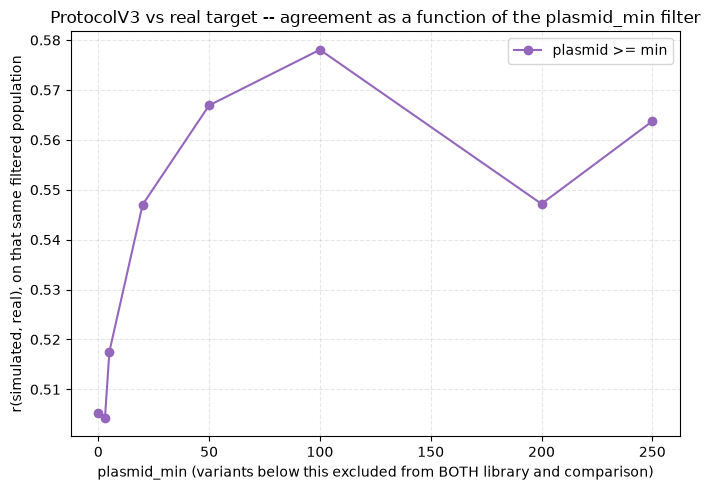

In [21]:
sweep_df = pd.DataFrame({pm: {k: v for k, v in r.items() if k not in ("target", "sim_target", "mask_finite")}
                          for pm, r in sweep_results.items()}).T
sweep_df.index.name = "plasmid_min"
display(sweep_df)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(sweep_df.index, sweep_df["r_sim_real"], marker="o", color="tab:purple", label="plasmid >= min")
ax.set_xlabel("plasmid_min (variants below this excluded from BOTH library and comparison)")
ax.set_ylabel("r(simulated, real), on that same filtered population")
ax.set_title("ProtocolV3 vs real target -- agreement as a function of the plasmid_min filter")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

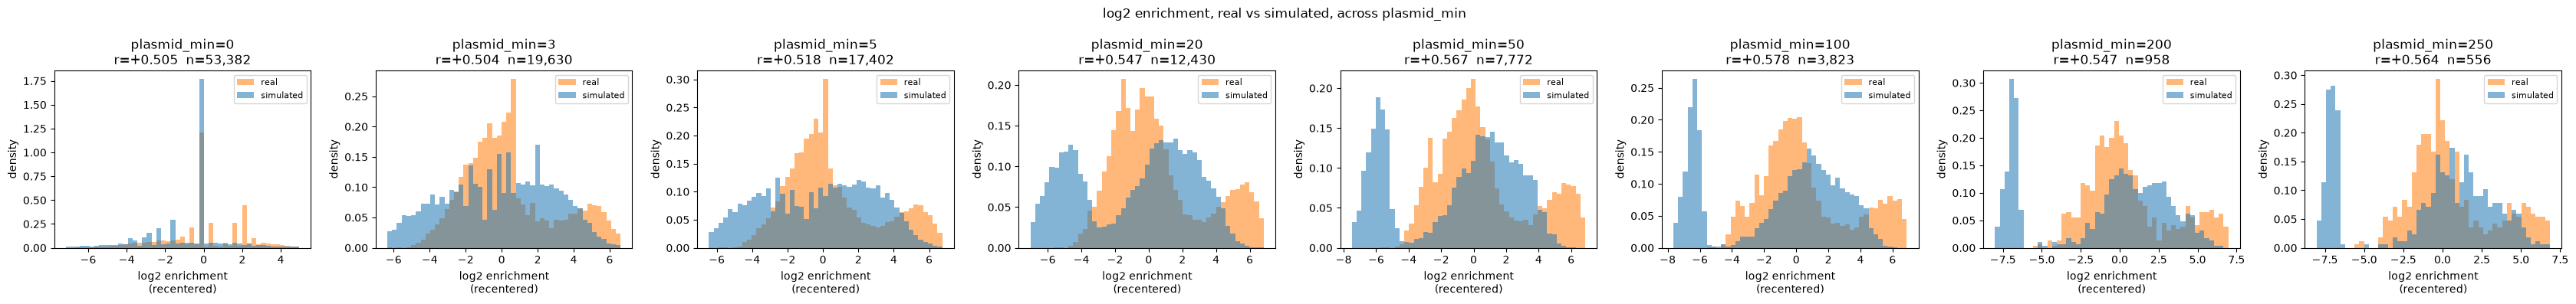

In [22]:
fig = plot_histogram_grid(sweep_results, title="log2 enrichment, real vs simulated, across plasmid_min",
                           label_fmt="plasmid_min={key}")
plt.show()

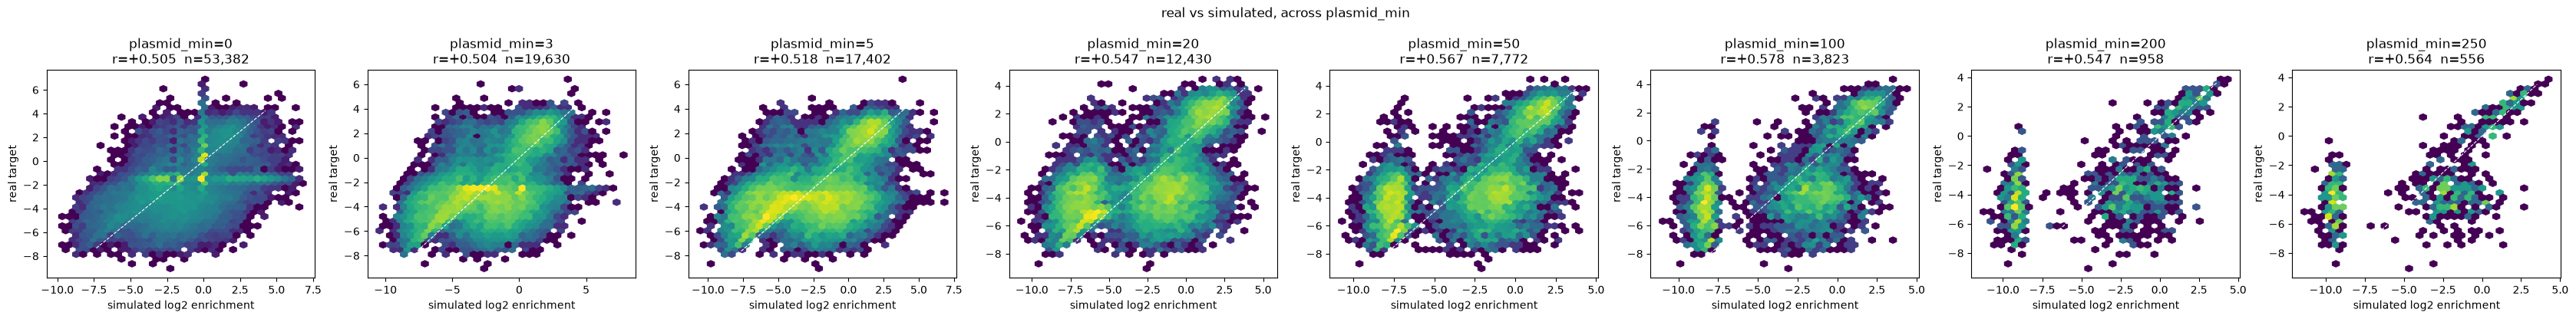

In [23]:
fig = plot_scatter_grid(sweep_results, title="real vs simulated, across plasmid_min",
                         label_fmt="plasmid_min={key}")
plt.show()

### 8d. Symmetric filter: bound BOTH `plasmid` and `vector` at the same minimum count

8b/8c only ever bounded `plasmid` (the library/lambda0-side checkpoint). Here the filter is
`plasmid >= min AND vector >= min` -- the same threshold applied to both checkpoints -- reusing
`run_filtered_protocol` on this different mask, same `PLASMID_MIN_SWEEP` thresholds for a direct,
same-x-axis comparison against 8c's plasmid-only curve.

In [24]:
sweep_results_sym = {}
for pm in PLASMID_MIN_SWEEP:
    res = run_filtered_protocol((plasmid >= pm) & (vector >= pm))
    sweep_results_sym[pm] = res
    print(f"min={pm:<3d} d0={res['d0']:>7,} ({res['frac_kept']:.1%})  "
          f"D/d0={res['reads_per_variant']:.1f} reads/variant  r(sim,real)={res['r_sim_real']:+.4f}")

min=0   d0= 53,382 (100.0%)  D/d0=26.2 reads/variant  r(sim,real)=+0.5052


min=3   d0= 10,963 (20.5%)  D/d0=112.9 reads/variant  r(sim,real)=+0.5020


min=5   d0=  8,891 (16.7%)  D/d0=132.8 reads/variant  r(sim,real)=+0.5141


min=20  d0=  4,068 (7.6%)  D/d0=233.6 reads/variant  r(sim,real)=+0.5533


min=50  d0=  2,099 (3.9%)  D/d0=357.0 reads/variant  r(sim,real)=+0.5863


min=100 d0=    935 (1.8%)  D/d0=539.2 reads/variant  r(sim,real)=+0.6125


min=200 d0=    213 (0.4%)  D/d0=974.7 reads/variant  r(sim,real)=+0.7811


min=250 d0=    125 (0.2%)  D/d0=1178.0 reads/variant  r(sim,real)=+0.7480


,d0,frac_kept,reads_per_variant,r_sim_real
min,,,,
0,53382.0,1.000000,26.180552,0.505214
3,10963.0,0.205369,112.895033,0.502046
5,8891.0,0.166554,132.778962,0.514121
20,4068.0,0.076205,233.579154,0.553253
50,2099.0,0.039320,356.999404,0.586260
100,935.0,0.017515,539.226738,0.612459
200,213.0,0.003990,974.651408,0.781120
250,125.0,0.002342,1177.960000,0.748016


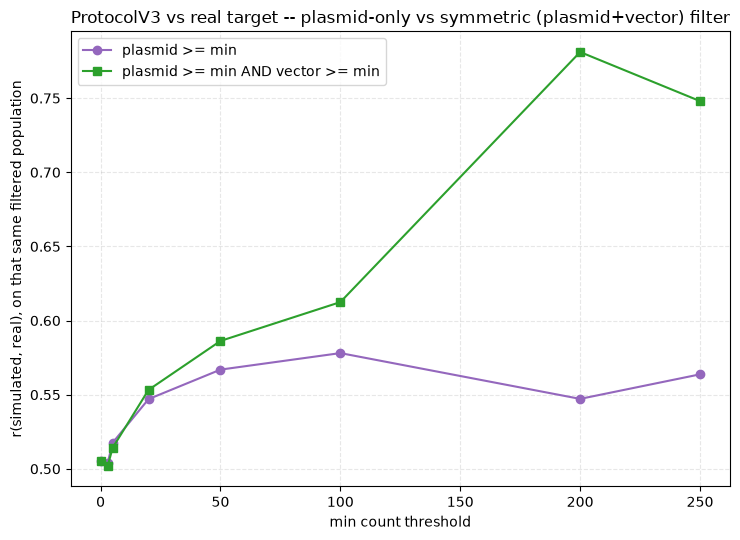

In [25]:
sweep_df_sym = pd.DataFrame({pm: {k: v for k, v in r.items() if k not in ("target", "sim_target", "mask_finite")}
                              for pm, r in sweep_results_sym.items()}).T
sweep_df_sym.index.name = "min"
display(sweep_df_sym)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ax.plot(sweep_df.index, sweep_df["r_sim_real"], marker="o", color="tab:purple", label="plasmid >= min")
ax.plot(sweep_df_sym.index, sweep_df_sym["r_sim_real"], marker="s", color="tab:green",
        label="plasmid >= min AND vector >= min")
ax.set_xlabel("min count threshold")
ax.set_ylabel("r(simulated, real), on that same filtered population")
ax.set_title("ProtocolV3 vs real target -- plasmid-only vs symmetric (plasmid+vector) filter")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

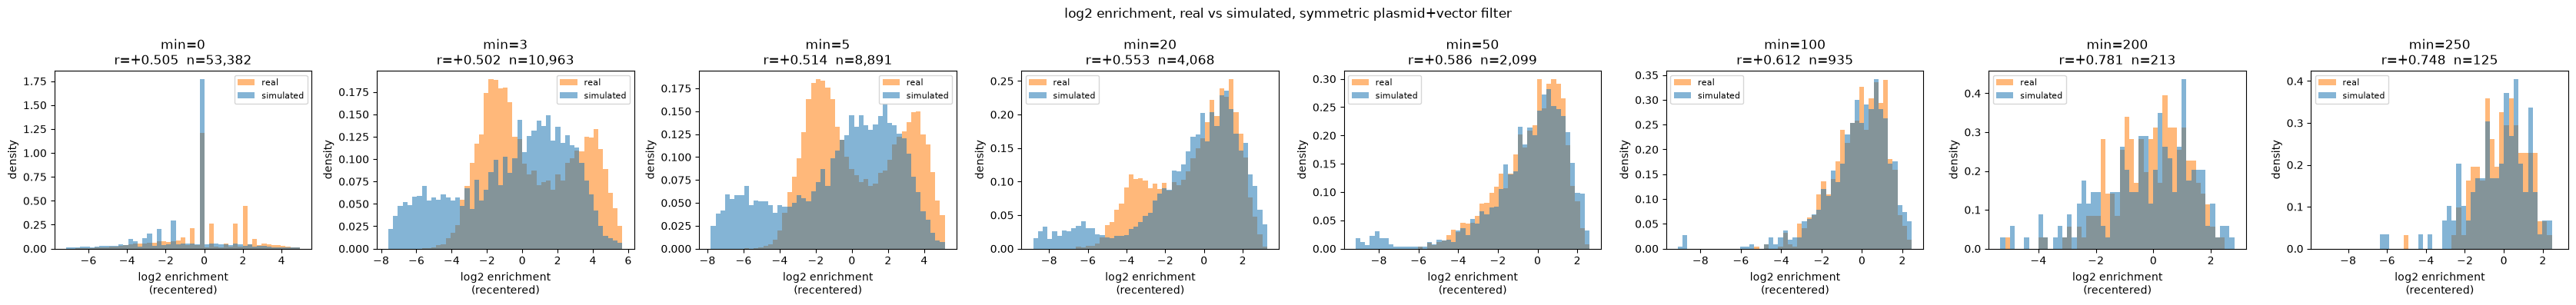

In [26]:
fig = plot_histogram_grid(sweep_results_sym, title="log2 enrichment, real vs simulated, symmetric plasmid+vector filter",
                           label_fmt="min={key}")
plt.show()

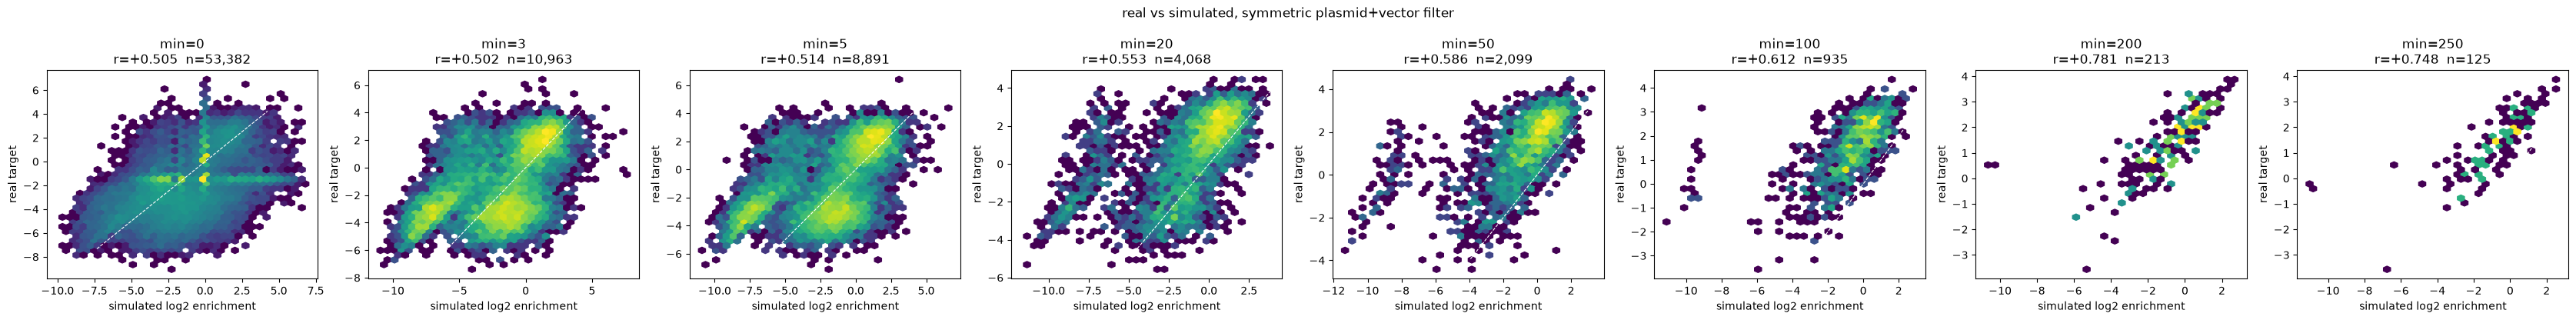

In [27]:
fig = plot_scatter_grid(sweep_results_sym, title="real vs simulated, symmetric plasmid+vector filter",
                         label_fmt="min={key}")
plt.show()

### 9. Export `aav2_F_viab_potts.npy` / `aav2_J_viab_potts.npy`

**⚠ Superseded (2026-09-16) -- see section 12c.** `aav2_F_viab_potts.npy` /
`aav2_J_viab_potts.npy` (the unfiltered fit below) are no longer the default AAV2 viability GT.
Kept in place for reference/comparison; the current default is the `plasmid_min=50, vector>0`
CV-fit exported in section 12c.

Full-data fit (section 3), not the `idx_train`-only fit from section 5 (that one is for held-out
validation only). Named without a suffix -- mirrors `aav9_F_viab_potts.npy`/`aav9_J_viab_potts.npy`,
the canonical Potts GT built directly from the eponymous CSV -- distinct from
`aav2_F_viab_potts_sorted_cv.npy`/`aav2_J_viab_potts_sorted_cv.npy` (fit on the unrelated IDV
organoid `AAV2_organoides_sorted.csv` in `Selectivity/AAV2/viability/sorting/`). Both are
gitignored (`Modelization_V2/lib/aav2_*_potts*.npy`), no `initialize_weights.py` loader added yet
(none of the `aav2_*_potts*` variants have one so far -- consistent with the rest of the project).

**⚠ Decision (2026-09-15, superseded 2026-09-16 -- cf. section 12c): `aav2_F_viab_potts.npy` /
`aav2_J_viab_potts.npy` (THIS notebook) were THE default AAV2 viability model for `ProtocolV3`
testing.** Fit on `Modelization_V1/notebooks/aav_viability_test/aav2.csv` -- 53,382 sequences,
LOW DIVERSITY.

The other `aav2_*_potts*.npy` files in `lib/` are a DIFFERENT lineage and are labeled here
explicitly so this isn't lost:

- `aav2_F_viab_potts_sorted_cv.npy` / `aav2_J_viab_potts_sorted_cv.npy`
- `aav2_F_viab_potts_top10k_cv.npy` / `aav2_J_viab_potts_top10k_cv.npy`

Both come from the IDV organoid `AAV2_organoides.csv` / `AAV2_organoides_sorted.csv` lineage
(`Selectivity/AAV2/viability/`, millions of real sequences before filtering) -- **HIGH DIVERSITY**
dataset. **Use them ONLY when explicitly comparing high-diversity vs low-diversity behavior for
viability -- never as the default weights for a `ProtocolV3` run going forward.**

In [28]:
F_VIAB_POTTS_PATH = LIB / "aav2_F_viab_potts.npy"
J_VIAB_POTTS_PATH = LIB / "aav2_J_viab_potts.npy"

np.save(F_VIAB_POTTS_PATH, np.array(F_potts, dtype=np.float32))
np.save(J_VIAB_POTTS_PATH, np.array(J_potts, dtype=np.float32))

print(f"Saved F_potts {np.array(F_potts).shape} to {F_VIAB_POTTS_PATH}")
print(f"Saved J_potts {np.array(J_potts).shape} to {J_VIAB_POTTS_PATH}")
lam_str = f"{info_full['lam']:.3g}" if info_full is not None else "n/a (F_potts/J_potts loaded from cache)"
r_potts_str = f"{r_potts:+.4f}" if r_potts is not None else "n/a (section 5 quoted out)"
print(f"(fit on all {len(df):,} sequences, CV lambda={lam_str}, "
      f"held-out r={r_potts_str} from section 5, ProtocolV3 recovery r={r_sim:+.4f} from section 8)")

Saved F_potts (20, 7) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav2_F_viab_potts.npy
Saved J_potts (7, 7, 20, 20) to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav2_J_viab_potts.npy
(fit on all 53,382 sequences, CV lambda=n/a (F_potts/J_potts loaded from cache), held-out r=n/a (section 5 quoted out) from section 5, ProtocolV3 recovery r=+0.5028 from section 8)


### 10. Canonical model: GT ceiling + 5 `ProtocolV3` replicates

From here on `F_potts`/`J_potts` (this notebook) are THE viability model used to test
`ProtocolV3` with AAV2 -- cf. the decision in section 9. Two checks on that exact model, both new
(neither was computed anywhere earlier in this notebook):

1. **GT ceiling**: Pearson r between the deterministic Potts score (`score_FJ(seq_matrix,
   F_potts, J_potts)`, no protocol/NGS noise at all) and the real `target` -- the best any noisy
   `ProtocolV3` simulation below could hope to match. Not the same number as `r_potts` (section 5,
   held-out prediction from an `idx_train`-only fit) or `r_sim` (section 8, one noisy simulated
   round) -- this is the full-data fit scored on its own training data, so it's an upper bound on
   both, not a fair generalization estimate.
2. **5 replicates**: `ProtocolV3` run 5 times (same `F_potts`/`J_potts`, same unfiltered
   53,382-sequence library, same `D`/`mu`/`T_viab`/`noise_viab` as section 8's current
   configuration -- just a different seed each time) -- pairwise Pearson r across the 10 replicate
   pairs shows how reproducible the simulated log2 enrichment itself is at this operating point,
   independent of any of sections 8b-8d's population filters.

In [29]:
_, _, gt_score = score_FJ(seq_matrix, np.array(F_potts), np.array(J_potts), baseline_full)
r_gt_ceiling = pearson(target, gt_score)
print(f"r(Potts deterministic score, real target) = {r_gt_ceiling:+.4f}   "
      f"(n={len(df):,}, no protocol/NGS noise -- ceiling for the replicates below)")

r(Potts deterministic score, real target) = +0.5235   (n=53,382, no protocol/NGS noise -- ceiling for the replicates below)


In [30]:
N_REPLICATES = 5

replicate_sim_targets = []
for seed in range(N_REPLICATES):
    protocol_r = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                             sequences=sequences, D=D, F_viab=F_viab_sim, J_viab=J_viab_sim,
                             F_sel=F_sel_sim, J_sel=J_sel_sim, noise_viab=NOISE_VIAB, noise_sel=0.5,
                             T_viab=T_VIAB, T_sel=1.0, multinomialNGS=True, rho=RHO)
    protocol_r.lambda0 = jnp.asarray(lambda0_init)
    _, ngs_r = protocol_r.loop_DE()
    l0p_r, l2p_r, _ = (np.asarray(a, np.float64) for a in ngs_r)
    sim_target_r = np.log2((l2p_r + EPS) / (l0p_r + EPS))
    replicate_sim_targets.append(sim_target_r)

    m_r = np.isfinite(target) & np.isfinite(sim_target_r)
    print(f"replicate seed={seed}  r(sim, real) = {pearson(target[m_r], sim_target_r[m_r]):+.4f}")

replicate seed=0  r(sim, real) = +0.5028


replicate seed=1  r(sim, real) = +0.4972


replicate seed=2  r(sim, real) = +0.4980


replicate seed=3  r(sim, real) = +0.4956


replicate seed=4  r(sim, real) = +0.5007


In [31]:
import itertools

pairwise_rows = []
for i, j in itertools.combinations(range(N_REPLICATES), 2):
    a, b = replicate_sim_targets[i], replicate_sim_targets[j]
    m_ij = np.isfinite(a) & np.isfinite(b)
    pairwise_rows.append(dict(rep_i=i, rep_j=j, r=pearson(a[m_ij], b[m_ij])))

pairwise_df = pd.DataFrame(pairwise_rows)
display(pairwise_df)
print(f"mean replicate-replicate r = {pairwise_df['r'].mean():+.4f}  "
      f"(min={pairwise_df['r'].min():+.4f}, max={pairwise_df['r'].max():+.4f})")

,rep_i,rep_j,r
0,0,1,0.528572
1,0,2,0.531817
2,0,3,0.531344
3,0,4,0.536735
4,1,2,0.527450
5,1,3,0.533546
6,1,4,0.532636
7,2,3,0.528663
8,2,4,0.528980
9,3,4,0.535871


mean replicate-replicate r = +0.5316  (min=+0.5275, max=+0.5367)


,seed=0,seed=1,seed=2,seed=3,seed=4
seed=0,1.0000,0.5286,0.5318,0.5313,0.5367
seed=1,0.5286,1.0000,0.5275,0.5335,0.5326
seed=2,0.5318,0.5275,1.0000,0.5287,0.5290
seed=3,0.5313,0.5335,0.5287,1.0000,0.5359
seed=4,0.5367,0.5326,0.5290,0.5359,1.0000


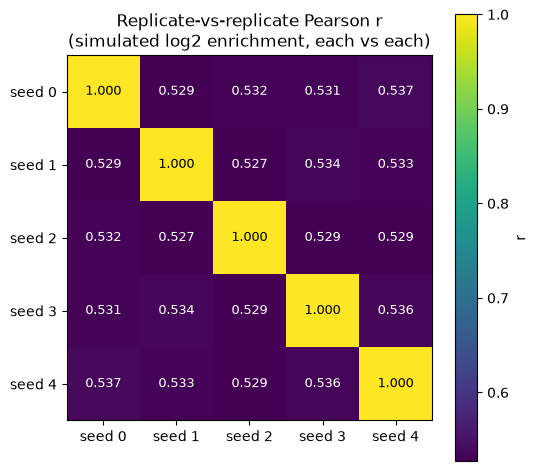

In [32]:
corr_matrix = np.eye(N_REPLICATES)
for i, j in itertools.combinations(range(N_REPLICATES), 2):
    a, b = replicate_sim_targets[i], replicate_sim_targets[j]
    m_ij = np.isfinite(a) & np.isfinite(b)
    corr_matrix[i, j] = corr_matrix[j, i] = pearson(a[m_ij], b[m_ij])

corr_df = pd.DataFrame(corr_matrix, index=[f"seed={s}" for s in range(N_REPLICATES)],
                        columns=[f"seed={s}" for s in range(N_REPLICATES)])
display(corr_df.round(4))

fig, ax = plt.subplots(figsize=(5.5, 5))
off_diag_vals = corr_matrix[~np.eye(N_REPLICATES, dtype=bool)]
im = ax.imshow(corr_matrix, cmap="viridis", vmin=off_diag_vals.min(), vmax=1.0)
ax.set_xticks(range(N_REPLICATES)); ax.set_xticklabels([f"seed {s}" for s in range(N_REPLICATES)])
ax.set_yticks(range(N_REPLICATES)); ax.set_yticklabels([f"seed {s}" for s in range(N_REPLICATES)])
for i in range(N_REPLICATES):
    for j in range(N_REPLICATES):
        ax.text(j, i, f"{corr_matrix[i, j]:.3f}", ha="center", va="center",
                color="white" if corr_matrix[i, j] < 0.85 else "black", fontsize=9)
ax.set_title("Replicate-vs-replicate Pearson r\n(simulated log2 enrichment, each vs each)")
fig.colorbar(im, ax=ax, label="r")
fig.tight_layout()
plt.show()

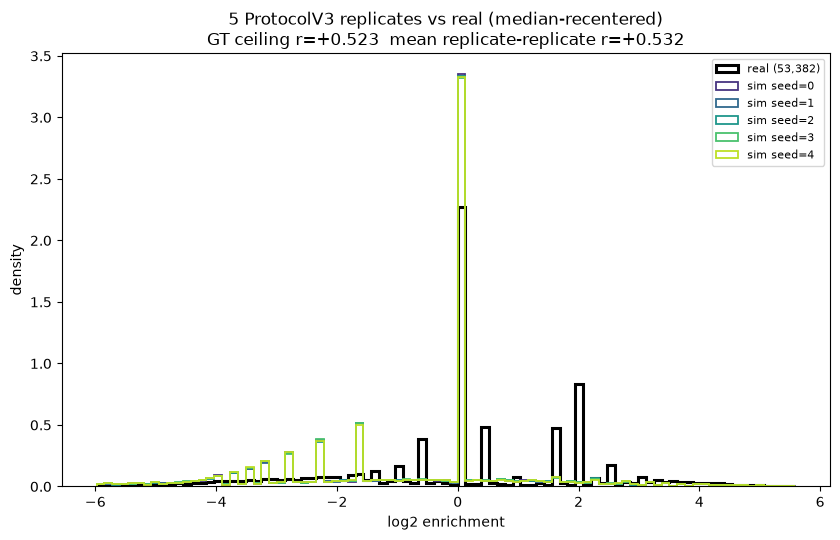

In [33]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

rv = center(target)
mfin = np.isfinite(rv)
lo, hi = np.percentile(rv[mfin], [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
ax.hist(rv[mfin], bins=bins, density=True, histtype="step", lw=2.2, color="black",
        label=f"real ({mfin.sum():,})")

colors = plt.cm.viridis(np.linspace(0.15, 0.9, N_REPLICATES))
for seed, (sim_t, color) in enumerate(zip(replicate_sim_targets, colors)):
    sv = center(sim_t)
    m2 = np.isfinite(sv)
    ax.hist(sv[m2], bins=bins, density=True, histtype="step", lw=1.3, color=color, label=f"sim seed={seed}")

ax.set(title=f"5 ProtocolV3 replicates vs real (median-recentered)\n"
             f"GT ceiling r={r_gt_ceiling:+.3f}  mean replicate-replicate r={pairwise_df['r'].mean():+.3f}",
       xlabel="log2 enrichment", ylabel="density")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 11. Potts regression sweep: does filtering by `plasmid_min` and vector detection improve the fit?

Revisits section 3's fit (on the full unfiltered library) along two filtering axes, to see
whether training on a cleaner subset gives a better Potts model:

- **`plasmid_min` sweep**: same thresholds as `PLASMID_MIN_SWEEP` (section 8c) -- variants with
  `plasmid < plasmid_min` excluded from the TRAINING set.
- **Vector detection**: at each `plasmid_min`, two variants -- `vector > 0` (a virus read was
  actually detected) vs `vector >= 0` (no additional requirement) -- to check whether excluding
  `vector == 0` rows helps. Motivation: a `plasmid>0, vector==0` row is ambiguous between "truly
  non-viable variant" and "a PCR/synthesis error mid-experiment produced physical DNA that no
  longer matches the designed sequence" (the same phenomenon `new_variant_appearance_analysis.ipynb`
  in `Modelization_V1` flags for AAV9); requiring `vector>0` doesn't distinguish the two, but at
  least removes rows where that ambiguity is most likely to matter.

Each of the 10 (`plasmid_min` x vector-filter) combinations gets its own Potts fit -- `lam=0`
(minimum-norm, no CV), same reasoning as `AAV5_SEL_potts_readout_depth.ipynb`'s sweeps: repeating
a full 5-fold CV 10 times is slow, and CV tends to degenerate to large lambdas on smaller filtered
populations anyway. `sample_weight` recomputed on each filtered subset (same `eps=0.5`
inverse-variance formula as section 2). Each fit is scored two ways: `r` against that SAME
filtered ("sorted") population, and `r` against the full 53,382-sequence RAW ("brut") population
-- a filter that overfits to its own subset but fails to generalize back to the raw data shows up
as a gap between the two.

In [34]:
VECTOR_FILTERS = {"vector > 0": lambda v: v > 0, "vector >= 0": lambda v: v >= 0}

fit_sweep_rows = []
for pm in PLASMID_MIN_SWEEP:
    for vf_label, vf_fn in VECTOR_FILTERS.items():
        mask_fit = (plasmid >= pm) & vf_fn(vector)
        n_fit = int(mask_fit.sum())

        w_fit = 1.0 / (1.0 / (vector[mask_fit] + 0.5) + 1.0 / (plasmid[mask_fit] + 0.5))
        F_s, J_s, rank_s, _ = R.fit_weights_potts_from_data_matrixfree(
            seq_matrix[mask_fit], target[mask_fit], sample_weight=w_fit, lam=0.0, verbose=False,
        )
        baseline_s = float(target[mask_fit].mean())

        _, _, score_sorted = score_FJ(seq_matrix[mask_fit], np.array(F_s), np.array(J_s), baseline_s)
        _, _, score_brut   = score_FJ(seq_matrix, np.array(F_s), np.array(J_s), baseline_s)

        m_sorted = np.isfinite(target[mask_fit]) & np.isfinite(score_sorted)
        m_brut   = np.isfinite(target) & np.isfinite(score_brut)
        r_sorted = pearson(target[mask_fit][m_sorted], score_sorted[m_sorted])
        r_brut   = pearson(target[m_brut], score_brut[m_brut])

        fit_sweep_rows.append(dict(plasmid_min=pm, vector_filter=vf_label, n_fit=n_fit,
                                    rank=rank_s, r_sorted=r_sorted, r_brut=r_brut))
        print(f"plasmid_min={pm:<3d} {vf_label:<12s} n_fit={n_fit:>7,}  "
              f"r(sorted)={r_sorted:+.4f}  r(brut)={r_brut:+.4f}")

fit_sweep_df = pd.DataFrame(fit_sweep_rows)
display(fit_sweep_df)

plasmid_min=0   vector > 0   n_fit= 26,099  r(sorted)=+0.6899  r(brut)=+0.4980
plasmid_min=0   vector >= 0  n_fit= 53,382  r(sorted)=+0.5341  r(brut)=+0.5341
plasmid_min=3   vector > 0   n_fit= 13,544  r(sorted)=+0.8031  r(brut)=+0.4662
plasmid_min=3   vector >= 0  n_fit= 19,630  r(sorted)=+0.6667  r(brut)=+0.4962
plasmid_min=5   vector > 0   n_fit= 12,881  r(sorted)=+0.8161  r(brut)=+0.4549
plasmid_min=5   vector >= 0  n_fit= 17,402  r(sorted)=+0.6962  r(brut)=+0.4846
plasmid_min=20  vector > 0   n_fit= 10,445  r(sorted)=+0.8687  r(brut)=+0.3795
plasmid_min=20  vector >= 0  n_fit= 12,430  r(sorted)=+0.7700  r(brut)=+0.4137
plasmid_min=50  vector > 0   n_fit=  7,076  r(sorted)=+0.9997  r(brut)=+0.2525
plasmid_min=50  vector >= 0  n_fit=  7,772  r(sorted)=+0.9753  r(brut)=+0.2156
plasmid_min=100 vector > 0   n_fit=  3,643  r(sorted)=+1.0000  r(brut)=+0.4330
plasmid_min=100 vector >= 0  n_fit=  3,823  r(sorted)=+1.0000  r(brut)=+0.4300
plasmid_min=200 vector > 0   n_fit=    951  r(sorted

,plasmid_min,vector_filter,n_fit,rank,r_sorted,r_brut
0,0,vector > 0,26099,None,0.689878,0.497957
1,0,vector >= 0,53382,None,0.534053,0.534053
2,3,vector > 0,13544,None,0.803135,0.466211
3,3,vector >= 0,19630,None,0.666654,0.496168
4,5,vector > 0,12881,None,0.816101,0.454938
5,5,vector >= 0,17402,None,0.696218,0.484596
6,20,vector > 0,10445,None,0.868685,0.379487
7,20,vector >= 0,12430,None,0.769958,0.413670
8,50,vector > 0,7076,None,0.999701,0.252542
9,50,vector >= 0,7772,None,0.975321,0.215587


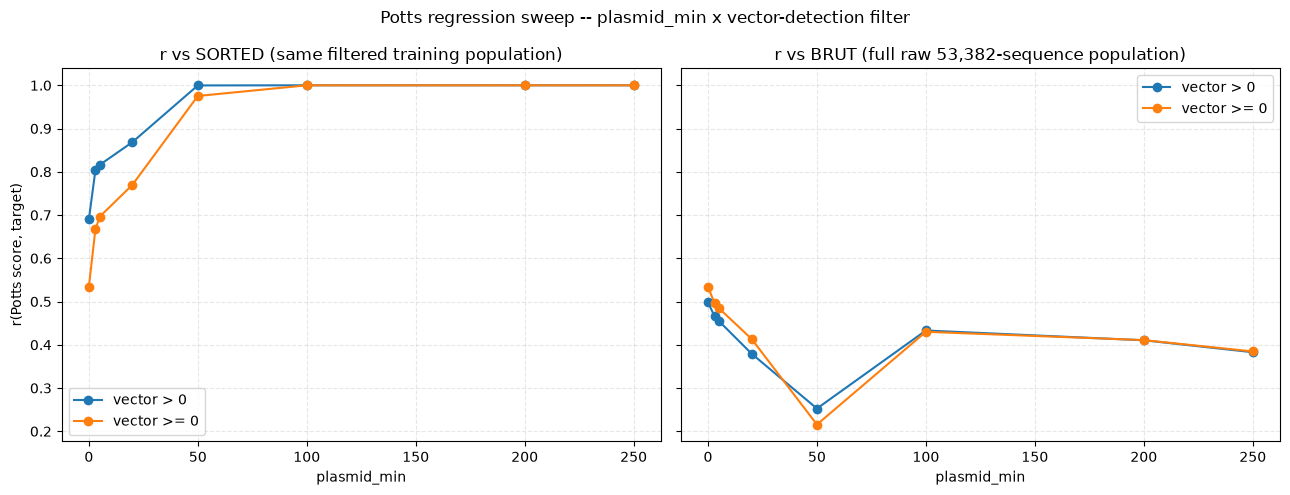

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for vf_label in VECTOR_FILTERS:
    sub = fit_sweep_df[fit_sweep_df["vector_filter"] == vf_label]
    axes[0].plot(sub["plasmid_min"], sub["r_sorted"], marker="o", label=vf_label)
    axes[1].plot(sub["plasmid_min"], sub["r_brut"], marker="o", label=vf_label)

axes[0].set(title="r vs SORTED (same filtered training population)",
            xlabel="plasmid_min", ylabel="r(Potts score, target)")
axes[1].set(title="r vs BRUT (full raw 53,382-sequence population)", xlabel="plasmid_min")
for ax in axes:
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.3)
fig.suptitle("Potts regression sweep -- plasmid_min x vector-detection filter")
fig.tight_layout()
plt.show()

### 12. CV-selected lambda Potts fit — `vector > 0`, `plasmid_min ∈ {20, 50}`

Section 11's sweep uses `lam=0` (minimum-norm, no CV) across all 16 (`plasmid_min` x
vector-filter) combinations, for speed. This section runs a full 5-fold CV lambda search
(same `LAMBDAS_GRID` as sections 3/5) for exactly the two combinations asked about here —
`vector > 0` at `plasmid_min=20` and at `plasmid_min=50` — to see whether CV lands on a real
interior lambda on these filtered subsets (rather than section 11's unregularized fit), and how
much that changes `r` relative to `lam=0` at the same thresholds. `sample_weight` is the same
`eps=0.5` inverse-variance formula as section 2/section 11, recomputed on each filtered subset.

In [36]:
CV_FILTER_THRESHOLDS = [20, 50]

cv_filter_results = {}
for pm in CV_FILTER_THRESHOLDS:
    mask_fit = (plasmid >= pm) & (vector > 0)
    n_fit = int(mask_fit.sum())

    w_fit = 1.0 / (1.0 / (vector[mask_fit] + 0.5) + 1.0 / (plasmid[mask_fit] + 0.5))
    F_cv, J_cv, rank_cv, info_cv = R.fit_weights_potts_from_data_matrixfree(
        seq_matrix[mask_fit], target[mask_fit], sample_weight=w_fit,
        lambdas_grid=LAMBDAS_GRID, seed=0, verbose=False,
    )
    baseline_cv = float(target[mask_fit].mean())

    _, _, score_sorted = score_FJ(seq_matrix[mask_fit], np.array(F_cv), np.array(J_cv), baseline_cv)
    _, _, score_brut   = score_FJ(seq_matrix, np.array(F_cv), np.array(J_cv), baseline_cv)

    m_sorted = np.isfinite(target[mask_fit]) & np.isfinite(score_sorted)
    m_brut   = np.isfinite(target) & np.isfinite(score_brut)
    r_sorted = pearson(target[mask_fit][m_sorted], score_sorted[m_sorted])
    r_brut   = pearson(target[m_brut], score_brut[m_brut])

    cv_filter_results[pm] = dict(F=F_cv, J=J_cv, rank=rank_cv, info=info_cv, n_fit=n_fit,
                                  cv_lambda=info_cv["lam"], r_sorted=r_sorted, r_brut=r_brut,
                                  target_sorted=target[mask_fit], score_sorted=score_sorted, m_sorted=m_sorted,
                                  score_brut=score_brut, m_brut=m_brut)
    print(f"plasmid_min={pm:<3d} vector>0   n_fit={n_fit:>7,}  "
          f"CV lambda={info_cv['lam']:.3g}  r(sorted)={r_sorted:+.4f}  r(brut)={r_brut:+.4f}")

cv_filter_df = pd.DataFrame({
    pm: {k: v for k, v in r.items() if k not in ("F", "J", "info", "target_sorted", "score_sorted",
                                                    "m_sorted", "score_brut", "m_brut")}
    for pm, r in cv_filter_results.items()
}).T
cv_filter_df.index.name = "plasmid_min"
display(cv_filter_df)

plasmid_min=20  vector>0   n_fit= 10,445  CV lambda=264  r(sorted)=+0.7892  r(brut)=+0.5424


plasmid_min=50  vector>0   n_fit=  7,076  CV lambda=264  r(sorted)=+0.8303  r(brut)=+0.5276


,rank,n_fit,cv_lambda,r_sorted,r_brut
plasmid_min,,,,,
20,NaN,10445.0,263.66509,0.789177,0.542415
50,NaN,7076.0,263.66509,0.830331,0.527584


In [37]:
if fit_sweep_df is not None:
    lam0_rows = fit_sweep_df[fit_sweep_df["vector_filter"] == "vector > 0"].set_index("plasmid_min")
    compare_rows = []
    for pm in CV_FILTER_THRESHOLDS:
        if pm in lam0_rows.index:
            compare_rows.append(dict(
                plasmid_min=pm,
                r_sorted_lam0=lam0_rows.loc[pm, "r_sorted"], r_sorted_cv=cv_filter_results[pm]["r_sorted"],
                r_brut_lam0=lam0_rows.loc[pm, "r_brut"], r_brut_cv=cv_filter_results[pm]["r_brut"],
                cv_lambda=cv_filter_results[pm]["cv_lambda"],
            ))
    if compare_rows:
        display(pd.DataFrame(compare_rows).set_index("plasmid_min"))
    else:
        print("fit_sweep_df has no rows at plasmid_min=20/50 for vector>0 -- check PLASMID_MIN_SWEEP.")
else:
    print("Run section 11 first (fit_sweep_df) for a side-by-side lam=0 vs CV comparison.")

,r_sorted_lam0,r_sorted_cv,r_brut_lam0,r_brut_cv,cv_lambda
plasmid_min,,,,,
20,0.868685,0.789177,0.379487,0.542415,263.66509
50,0.999701,0.830331,0.252542,0.527584,263.66509


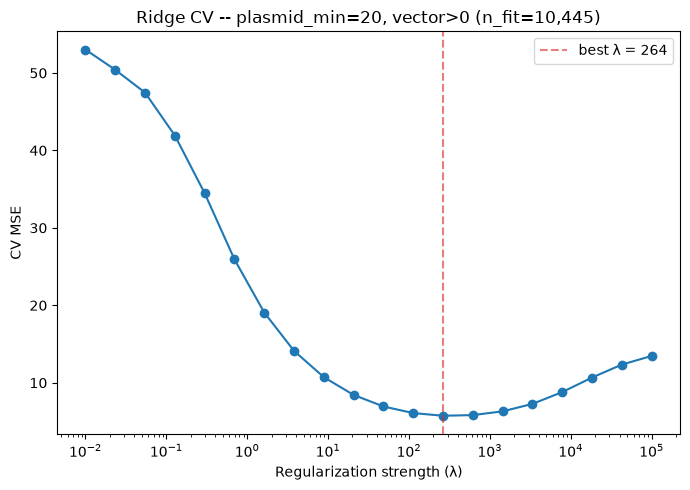

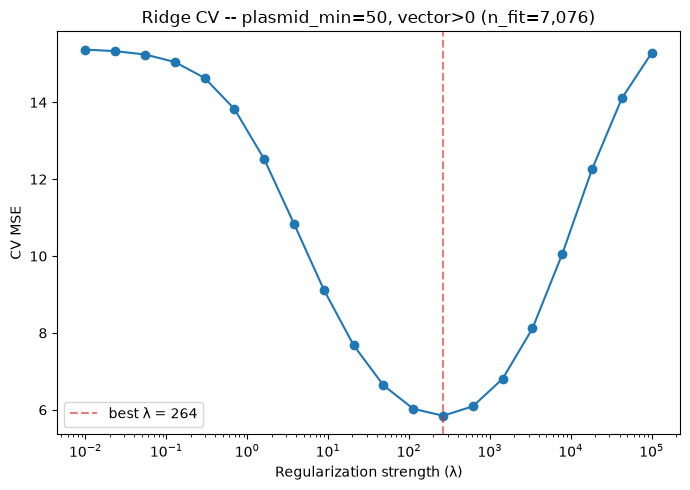

In [38]:
for pm in CV_FILTER_THRESHOLDS:
    info_cv = cv_filter_results[pm]["info"]
    fig = plot_cv_curve(info_cv["lambdas_grid"], info_cv["cv_mse"],
                         title=f"Ridge CV -- plasmid_min={pm}, vector>0 (n_fit={cv_filter_results[pm]['n_fit']:,})")
    plt.show()

**Score vs real log2 enrichment**, both populations for each threshold -- same hexbin + y=x
style as `plot_scatter_grid` (section 8/8b), adapted here to a Potts regression score, which is
already on the same scale as `target` (no `T_viab` rescaling issue like the `ProtocolV3`
simulated-vs-GT panels elsewhere in this notebook).

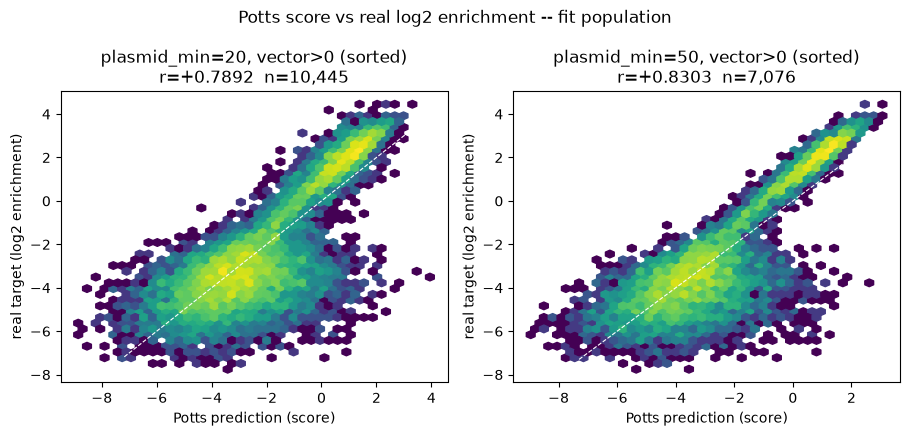

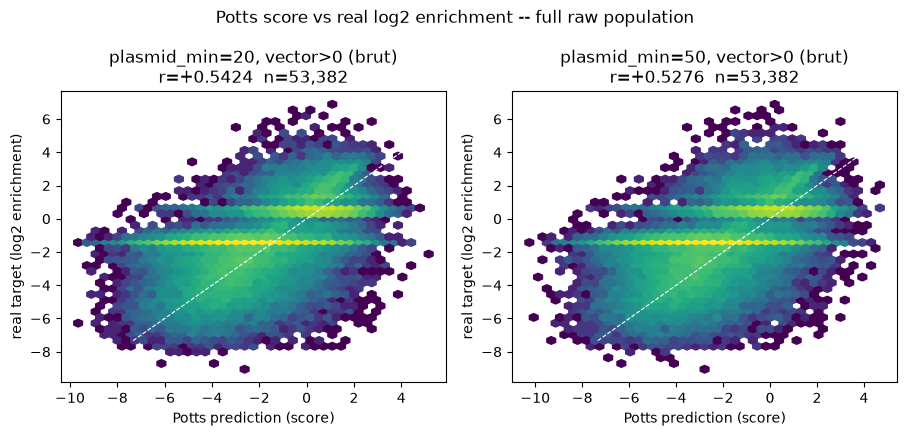

In [39]:
def plot_score_vs_real_grid(results, population, title):
    """population: 'sorted' (fit population, mask_fit) or 'brut' (full raw 53,382-sequence
    population) -- one hexbin panel per plasmid_min threshold in `results`."""
    keys = list(results)
    fig, axes = plt.subplots(1, len(keys), figsize=(4.6 * len(keys), 4.4))
    if len(keys) == 1:
        axes = [axes]
    for ax, pm in zip(axes, keys):
        res = results[pm]
        if population == "sorted":
            score, y_real, m, r = res["score_sorted"], res["target_sorted"], res["m_sorted"], res["r_sorted"]
        else:
            score, y_real, m, r = res["score_brut"], target, res["m_brut"], res["r_brut"]
        x, y = score[m], y_real[m]
        ax.hexbin(x, y, gridsize=40, bins="log", cmap="viridis", mincnt=1)
        d = [max(x.min(), np.percentile(y, 0.2)), min(x.max(), np.percentile(y, 99.8))]
        ax.plot(d, d, "w--", lw=0.8)
        ax.set_xlabel("Potts prediction (score)")
        ax.set_ylabel("real target (log2 enrichment)")
        ax.set_title(f"plasmid_min={pm}, vector>0 ({population})\nr={r:+.4f}  n={m.sum():,}")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig = plot_score_vs_real_grid(cv_filter_results, "sorted",
                               "Potts score vs real log2 enrichment -- fit population")
plt.show()

fig = plot_score_vs_real_grid(cv_filter_results, "brut",
                               "Potts score vs real log2 enrichment -- full raw population")
plt.show()

### 12b. `ProtocolV3` test with these CV-fit weights — histograms, scatter, and reproducibility across replicates

For each of section 12's two weight sets, run the mechanistic `ProtocolV3` (viability-only,
`F_sel=J_sel=0`) on that SAME filtered population it was fit on (`plasmid >= plasmid_min AND
vector > 0`) — same recipe as section 8b/8c (`lambda0(s) = plasmid(s) * dilution_factor`, `D`
recalibrated to that population's own real reads/variant ratio), except each threshold uses its
OWN `F_cv`/`J_cv` (`cv_filter_results[pm]["F"]`/`["J"]`) instead of section 8's shared
`F_potts`/`J_potts` — `run_protocol_with_weights` below is `run_filtered_protocol` (section 8c)
with `F_viab`/`J_viab` taken as parameters instead of reading the section-8 globals, needed for
exactly this reason. Reuses `plot_histogram_grid`/`plot_scatter_grid` (section 8c) unchanged —
both just read `target`/`sim_target`/`mask_finite`/`r_sim_real` off whatever dict they're given.

`N_PROTOCOL_REPLICATES=5` stochastic draws (different seed each time, same weights/mask/`D`) per
threshold, to see how much `r(sim, real)` varies run-to-run relative to the gap between the two
`plasmid_min` thresholds and relative to each threshold's own deterministic `r_sorted` (Potts
score) ceiling from section 12. `seed=0`'s draw is reused as the single representative run for
the histogram/scatter panels below, instead of simulating it twice.

In [40]:
def run_protocol_with_weights(mask, F_viab, J_viab, seed=0):
    """Like `run_filtered_protocol` (section 8c), but takes F_viab/J_viab as parameters
    instead of reading the global F_viab_sim/J_viab_sim -- needed here since each
    cv_filter_results[pm] fit has its OWN F/J (fit only on that threshold's own filtered
    subset), unlike section 8c/8d's sweep which reused one shared F_potts/J_potts across
    every mask."""
    d0_s = int(mask.sum())
    sequences_s = jnp.asarray(seq_matrix[mask])
    plasmid_s = plasmid[mask]
    vector_s  = vector[mask]
    target_s  = target[mask]

    N1_s = MU * d0_s / RHO
    lambda0_init_s = plasmid_s * DILUTION
    N0_s = float(lambda0_init_s.sum())
    D_s  = float((plasmid_s.sum() + vector_s.sum()) / 2)

    F_viab_j = jnp.asarray(np.array(F_viab))
    J_viab_j = jnp.asarray(np.array(J_viab))
    F_sel_j  = jnp.zeros_like(F_viab_j)
    J_sel_j  = jnp.zeros_like(J_viab_j)

    protocol_s = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0_s, N1=N1_s, dilution_factor=DILUTION,
                             sequences=sequences_s, D=D_s, F_viab=F_viab_j, J_viab=J_viab_j,
                             F_sel=F_sel_j, J_sel=J_sel_j, noise_viab=NOISE_VIAB, noise_sel=0.5,
                             T_viab=T_VIAB, T_sel=1.0, multinomialNGS=True, rho=RHO)
    protocol_s.lambda0 = jnp.asarray(lambda0_init_s)
    _, ngs_s = protocol_s.loop_DE()
    l0p_s, l2p_s, _ = (np.asarray(a, np.float64) for a in ngs_s)
    sim_target_s = np.log2((l2p_s + EPS) / (l0p_s + EPS))

    m_s = np.isfinite(target_s) & np.isfinite(sim_target_s)
    r_s = pearson(target_s[m_s], sim_target_s[m_s])
    return dict(d0=d0_s, frac_kept=float(mask.mean()), reads_per_variant=D_s / d0_s,
                r_sim_real=r_s, target=target_s, sim_target=sim_target_s, mask_finite=m_s)

In [41]:
N_PROTOCOL_REPLICATES = 5

cv_protocol_replicates = {pm: [] for pm in CV_FILTER_THRESHOLDS}
for pm in CV_FILTER_THRESHOLDS:
    mask_pm = (plasmid >= pm) & (vector > 0)
    for seed in range(N_PROTOCOL_REPLICATES):
        res = run_protocol_with_weights(mask_pm, cv_filter_results[pm]["F"], cv_filter_results[pm]["J"],
                                         seed=seed)
        cv_protocol_replicates[pm].append(res)
        print(f"plasmid_min={pm:<3d} vector>0  seed={seed}  d0={res['d0']:>7,}  "
              f"D/d0={res['reads_per_variant']:.1f} reads/variant  r(sim,real)={res['r_sim_real']:+.4f}")

cv_protocol_results = {pm: reps[0] for pm, reps in cv_protocol_replicates.items()}  # seed=0 -- representative run

plasmid_min=20  vector>0  seed=0  d0= 10,445  D/d0=119.3 reads/variant  r(sim,real)=+0.7361


plasmid_min=20  vector>0  seed=1  d0= 10,445  D/d0=119.3 reads/variant  r(sim,real)=+0.7395


plasmid_min=20  vector>0  seed=2  d0= 10,445  D/d0=119.3 reads/variant  r(sim,real)=+0.7364


plasmid_min=20  vector>0  seed=3  d0= 10,445  D/d0=119.3 reads/variant  r(sim,real)=+0.7366


plasmid_min=20  vector>0  seed=4  d0= 10,445  D/d0=119.3 reads/variant  r(sim,real)=+0.7371


plasmid_min=50  vector>0  seed=0  d0=  7,076  D/d0=153.3 reads/variant  r(sim,real)=+0.7695


plasmid_min=50  vector>0  seed=1  d0=  7,076  D/d0=153.3 reads/variant  r(sim,real)=+0.7743


plasmid_min=50  vector>0  seed=2  d0=  7,076  D/d0=153.3 reads/variant  r(sim,real)=+0.7710


plasmid_min=50  vector>0  seed=3  d0=  7,076  D/d0=153.3 reads/variant  r(sim,real)=+0.7706


plasmid_min=50  vector>0  seed=4  d0=  7,076  D/d0=153.3 reads/variant  r(sim,real)=+0.7708


In [42]:
r_replicate_df = pd.DataFrame({pm: [res["r_sim_real"] for res in reps]
                                for pm, reps in cv_protocol_replicates.items()})
r_replicate_df.index.name = "seed"
display(r_replicate_df)

summary_rows = []
for pm, reps in cv_protocol_replicates.items():
    r_vals = np.array([res["r_sim_real"] for res in reps])
    summary_rows.append(dict(plasmid_min=pm, r_mean=r_vals.mean(), r_std=r_vals.std(),
                              r_score_sorted_ceiling=cv_filter_results[pm]["r_sorted"]))
cv_protocol_summary = pd.DataFrame(summary_rows).set_index("plasmid_min")
display(cv_protocol_summary)

,20,50
seed,,
0,0.736110,0.769548
1,0.739545,0.774274
2,0.736383,0.770975
3,0.736637,0.770582
4,0.737110,0.770752


,r_mean,r_std,r_score_sorted_ceiling
plasmid_min,,,
20,0.737157,0.001239,0.789177
50,0.771226,0.001601,0.830331


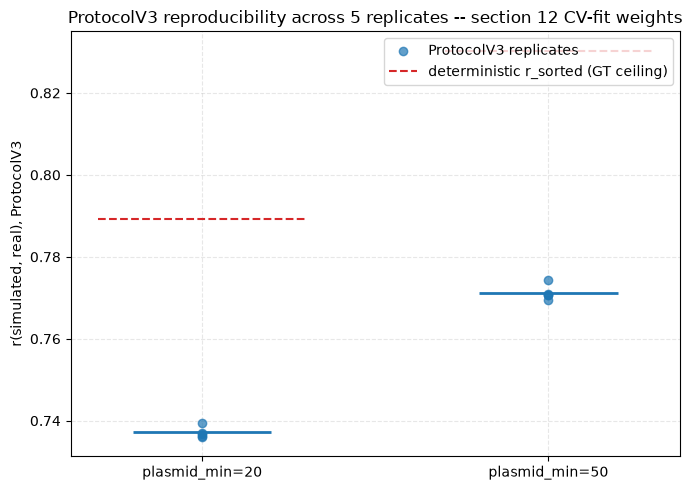

In [43]:
fig, ax = plt.subplots(figsize=(7, 5))
for i, pm in enumerate(CV_FILTER_THRESHOLDS):
    r_vals = [res["r_sim_real"] for res in cv_protocol_replicates[pm]]
    ax.scatter([i] * len(r_vals), r_vals, color="tab:blue", alpha=0.7, zorder=3,
               label="ProtocolV3 replicates" if i == 0 else None)
    ax.hlines(np.mean(r_vals), i - 0.2, i + 0.2, color="tab:blue", linewidth=2, zorder=4)
    ax.hlines(cv_filter_results[pm]["r_sorted"], i - 0.3, i + 0.3, color="tab:red", linestyle="--",
              zorder=4, label="deterministic r_sorted (GT ceiling)" if i == 0 else None)
ax.set_xticks(range(len(CV_FILTER_THRESHOLDS)))
ax.set_xticklabels([f"plasmid_min={pm}" for pm in CV_FILTER_THRESHOLDS])
ax.set_ylabel("r(simulated, real), ProtocolV3")
ax.set_title(f"ProtocolV3 reproducibility across {N_PROTOCOL_REPLICATES} replicates -- section 12 CV-fit weights")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

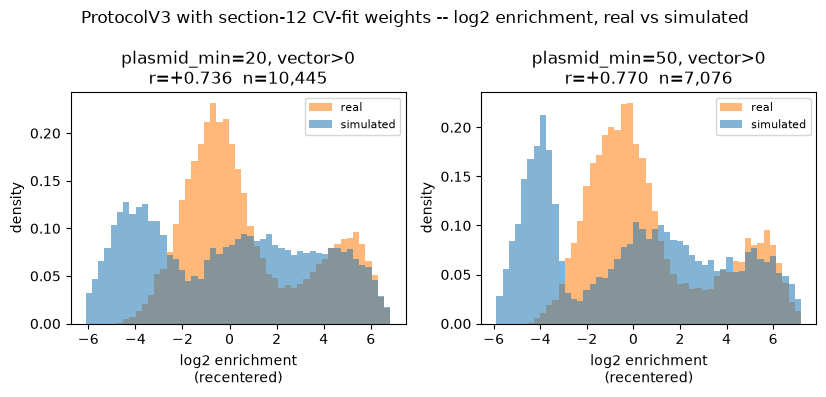

In [44]:
fig = plot_histogram_grid(cv_protocol_results,
                           title="ProtocolV3 with section-12 CV-fit weights -- log2 enrichment, real vs simulated",
                           label_fmt="plasmid_min={key}, vector>0")
plt.show()

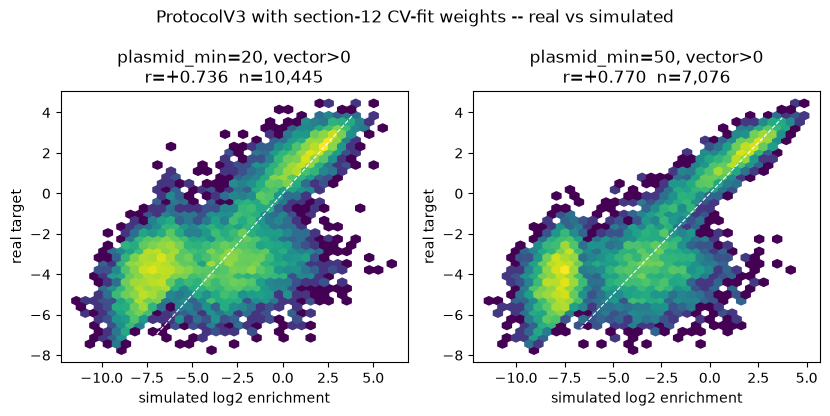

In [45]:
fig = plot_scatter_grid(cv_protocol_results,
                         title="ProtocolV3 with section-12 CV-fit weights -- real vs simulated",
                         label_fmt="plasmid_min={key}, vector>0")
plt.show()

### 12c. Decision (2026-09-16): `plasmid_min=50, vector>0` (CV-fit) is now THE canonical AAV2
viability GT

**Supersedes section 9's decision.** From now on, `aav2_F_viab_potts_plasmid50_vectorpos_cv.npy` /
`aav2_J_viab_potts_plasmid50_vectorpos_cv.npy` -- the CV-selected-lambda Potts fit on
`plasmid >= 50 AND vector > 0` from section 12 -- are THE default AAV2 viability GT for
`ProtocolV3` testing and any other downstream use, replacing the unfiltered full-53,382-sequence
fit (`aav2_F_viab_potts.npy` / `aav2_J_viab_potts.npy`, section 3/9). That unfiltered fit is left
in place for reference/comparison, not deleted.

The other `aav2_*_potts*.npy` lineage in `lib/` (`_sorted_cv`, `_top10k_cv` -- the IDV organoid
`AAV2_organoides*.csv`, HIGH DIVERSITY, cf. section 9) is unaffected by this decision: still only
for explicit high- vs low-diversity comparisons, never a default.

In [46]:
F_VIAB_POTTS_P50_PATH = LIB / "aav2_F_viab_potts_plasmid50_vectorpos_cv.npy"
J_VIAB_POTTS_P50_PATH = LIB / "aav2_J_viab_potts_plasmid50_vectorpos_cv.npy"

np.save(F_VIAB_POTTS_P50_PATH, np.array(cv_filter_results[50]["F"], dtype=np.float32))
np.save(J_VIAB_POTTS_P50_PATH, np.array(cv_filter_results[50]["J"], dtype=np.float32))

print(f"Saved F to {F_VIAB_POTTS_P50_PATH}")
print(f"Saved J to {J_VIAB_POTTS_P50_PATH}")
print(f"(fit on plasmid_min=50, vector>0, n_fit={cv_filter_results[50]['n_fit']:,}, "
      f"CV lambda={cv_filter_results[50]['cv_lambda']:.3g}, "
      f"r_sorted={cv_filter_results[50]['r_sorted']:+.4f}, r_brut={cv_filter_results[50]['r_brut']:+.4f})")

Saved F to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav2_F_viab_potts_plasmid50_vectorpos_cv.npy
Saved J to /home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/Modelization_V2/lib/aav2_J_viab_potts_plasmid50_vectorpos_cv.npy
(fit on plasmid_min=50, vector>0, n_fit=7,076, CV lambda=264, r_sorted=+0.8303, r_brut=+0.5276)
